In [1]:
import os
import typing
from dask_jobqueue import PBSCluster
from pathlib import Path

# Define the working directory path
working_directory = str(Path.cwd())

# Launch a scheduler and workers on HPC via PBS
cluster = PBSCluster(
     cores=4,
     memory="8GB",
     processes=1,
     queue="tamirQ",
     walltime="02:30:00",
     scheduler_options={"dashboard_address": ":12435"},  # FIXME - this is the port we need to define...
     # Additional custom options
     log_directory="dask-logs",
     #worker_extra_args=["--lifetime", "25m", "--lifetime-stagger", "4m"],  # for walltime="00:30:00"
     job_script_prologue=[f"cd {working_directory}"]
)
cluster
cluster.adapt(minimum=10, maximum=60)
print(cluster.job_script())
from dask.distributed import Client, progress, wait, get_client, get_worker
client = Client(cluster)
client

#!/usr/bin/env bash

#PBS -N dask-worker
#PBS -q tamirQ
#PBS -l select=1:ncpus=4:mem=7630MB
#PBS -l walltime=02:30:00
#PBS -e dask-logs/
#PBS -o dask-logs/
cd /tamir2/moranb/microbiome/Igem_TAU_2021
/tamir2/moranb/microbiome/Igem_TAU_2021/venv/bin/python -m distributed.cli.dask_worker tcp://132.66.112.146:42656 --nthreads 4 --memory-limit 7.45GiB --name dummy-name --nanny --death-timeout 60



Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: http://132.66.112.146:12435/status,
Dashboard: http://132.66.112.146:12435/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://132.66.112.146:42656,Workers: 0
Dashboard: http://132.66.112.146:12435/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [2]:
import dask.bag as db
import dask.dataframe as dd
from dask import delayed, compute, persist
from pandas.core.dtypes.common import pandas_dtype as dtype
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from pathlib import Path
import seaborn as sns
import operator
from Bio import SeqIO, AlignIO
from analysis.input_testing_data.generate_input_testing_data_for_modules import generate_testing_data
from analysis.input_testing_data.generate_input_testing_data_for_modules import generate_testing_data_for_ecoli_and_bacillus




In [3]:
import os, sys, pathlib

sys.path.insert(0, "/tamir2/moranb/microbiome/Igem_TAU_2021/app")

In [4]:
print("sys.path first entries:", sys.path[:5])

print("logger_factory dir exists:",
      os.path.isdir("/tamir2/moranb/microbiome/Igem_TAU_2021/app/logger_factory"))

print("init exists:",
      os.path.isfile("/tamir2/moranb/microbiome/Igem_TAU_2021/app/logger_factory/__init__.py"))

print("module exists:",
      os.path.isfile("/tamir2/moranb/microbiome/Igem_TAU_2021/app/logger_factory/logger_factory.py"))

from app.modules.main import run_modules
from modules.user_IO.input_functions import extract_gene_data

sys.path first entries: ['/tamir2/moranb/microbiome/Igem_TAU_2021/app', '/var/tmp/pbs.5790401.power9.tau.ac.il/dask-scratch-space/scheduler-do9xn172', '/tamir2/moranb/microbiome/Igem_TAU_2021', '/powerapps/share/centos7/miniconda/miniconda3-4.7.12-environmentally/envs/Python3.9Plus/lib/python39.zip', '/powerapps/share/centos7/miniconda/miniconda3-4.7.12-environmentally/envs/Python3.9Plus/lib/python3.9']
logger_factory dir exists: True
init exists: True
module exists: True


In [5]:
output_path = "/tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis"
optimization_cub_index = "CAI"

variant_names = [
    "single_diff",
    "zscore_bulk_diff",
    "single_ratio",
    "zscore_bulk_ratio",
]
variant_scores_names = ["{score}_" + variant_name for variant_name in variant_names]

average_distance_score_variant_names = [s.format(score="average_distance_score") for s in variant_scores_names]
ratio_score_variant_names = [s.format(score="ratio_score") for s in variant_scores_names]

In [6]:
def get_orf_summary(summary: typing.Dict[str, typing.Any], evaluation_method: str = "average_distance_score") -> typing.Dict[str, typing.Any]:
    if len(summary["evaluation"]) == 1:
        return summary["orf"]
    final_evaluation = summary["final_evaluation"]
    for i, evaluation_summary in enumerate(summary["evaluation"]):
        if evaluation_summary[evaluation_method] == final_evaluation[evaluation_method]:
            return summary["orf"][i]

def get_total_run_time(summary: typing.Dict[str, typing.Any]) -> float:
     if len(summary["evaluation"]) == 1:
        return summary["orf"]["run_time"]
     run_time = 0
     for orf_summary in summary["orf"]:
         run_time += orf_summary["run_time"]
     return run_time

def extract_organism_name_from_path(organism_path):
    return organism_path.split("/")[-1].removesuffix(".gbff")

def extract_organism_names(organism_paths):
    if isinstance(organism_paths, str):
        return extract_organism_name_from_path(organism_paths)
    return "|".join(sorted([extract_organism_name_from_path(organism_path) for organism_path in organism_paths]))
    
def convert_json(x):
    configuration = x["configuration"]
    result = x["result"]
    orf = get_orf_summary(result)
    if "orf" not in result or orf is None: # probably thrown in case of an error
        return {
            "error_message": result,
        }
    run_time = get_total_run_time(result)
    iterations_count = str(orf.get("iterations_count", 1))
    return {
        "wanted_organisms": extract_organism_names(configuration[0]),
        "unwanted_organisms": extract_organism_names(configuration[1]),
        "initial_optimization_score": orf.get("initial_sequence_optimization_score"),
        "final_optimization_score": orf.get("final_sequence_optimization_score"),
        "average_distance_score": result["final_evaluation"].get("average_distance_score"),
        "average_distance_non_normalized_score": result["final_evaluation"].get("average_distance_non_normalized_score"),
        "weakest_link_score": result["final_evaluation"].get("weakest_link_score"),
        "ratio_score": result["final_evaluation"].get("ratio_score"),
        "orf_optimization_cub_index": result["module_input"].get("orf_optimization_cub_index"),
        "evaluation_score": result["module_input"].get("evaluation_score"),
        "run_time": run_time,
        "iterations_count": iterations_count,
        "final_sequence": result["final_evaluation"].get("final_sequence"),
    }

def json_map(x):
    x = x.strip("\n")
    result = None
    try:
        result = json.loads(x)
        return convert_json(result)
    except Exception as e:
        return {"error_message": "bad json string: " + str(e), "input": x}

In [7]:
def get_df_for_run_configuration(configuration, optimization_method, is_debug=False):
    configuration_output_path = os.path.join(output_path, configuration)
    debug_suffix = '-debug' if is_debug else ''
    results_dir = F"{os.path.join(configuration_output_path, optimization_method + debug_suffix)}"
    print(f"results dir is: {results_dir}")
    file_names = [str(file) for file in list(Path(results_dir).rglob("*.json"))]
    print(f"found {len(file_names)} files")
    bag = db.read_text(file_names).map(json_map)

    error_records = bag.filter(lambda x: "error_message" in x.keys())
    valid_records = bag.filter(lambda x: "error_message" not in x.keys())
    # return valid_records.compute(), error_records.compute()
    return valid_records.to_dataframe().compute(), error_records.compute()

    # return dd.read_json([str(file) for file in list(Path(results_dir).rglob("*.json"))], orient='records', lines=True)
    
def get_scores_df_by_configuration_df(configuration, is_debug=False, include_single_organism=True):
    df_bulk_zscore_ratio, df_bulk_zscore_ratio_errors = get_df_for_run_configuration(configuration, "zscore_bulk_aa_ratio", is_debug)
    df_bulk_zscore_diff, df_bulk_zscore_diff_errors = get_df_for_run_configuration(configuration, "zscore_bulk_aa_diff", is_debug)
    merged_bulk_zscore_df = dd.merge(df_bulk_zscore_ratio, df_bulk_zscore_diff, on=['wanted_organisms', 'unwanted_organisms'], how='inner', suffixes=('_zscore_bulk_ratio', '_zscore_bulk_diff'))

    # df_single_zscore_ratio, df_single_zscore_ratio_errors = get_df_for_run_configuration(configuration, "zscore_single_aa_ratio", is_debug)
    # df_single_zscore_diff, df_single_zscore_diff_errors = get_df_for_run_configuration(configuration, "zscore_single_aa_diff", is_debug)
    # merged_single_zscore_df = dd.merge(df_single_zscore_ratio, df_single_zscore_diff, on='gene_name', how='inner', suffixes=('_zscore_single_ratio', '_zscore_single_diff'))

    df_single_codon_ratio, df_single_codon_ratio_error = get_df_for_run_configuration(configuration, "single_codon_ratio", is_debug)
    df_single_codon_diff, df_single_codon_diff_error = get_df_for_run_configuration(configuration, "single_codon_diff", is_debug)
    merged_single_df = dd.merge(df_single_codon_ratio, df_single_codon_diff, on=['wanted_organisms', 'unwanted_organisms'], how='inner', suffixes=('_single_ratio', '_single_diff'))
    
    # merged_df = dd.merge(merged_bulk_zscore_df, merged_single_zscore_df, on='gene_name', how='inner')
    merged_df = dd.merge(merged_bulk_zscore_df, merged_single_df, on=['wanted_organisms', 'unwanted_organisms'], how='inner')

    if include_single_organism:
        df_single_wanted_organism, df_single_wanted_organism_error = get_df_for_run_configuration(configuration, "single_wanted_organism", is_debug)
        merged_df = dd.merge(merged_df, df_single_wanted_organism, on=['wanted_organisms', 'unwanted_organisms'], how='inner')

        merged_df = merged_df.rename(columns={
            'initial_optimization_score': 'initial_optimization_score_single_wanted_organism',
            'final_optimization_score': 'final_optimization_score_single_wanted_organism',
            'average_distance_score': 'average_distance_score_single_wanted_organism',
            'average_distance_non_normalized_score': 'average_distance_non_normalized_score_single_wanted_organism',
            'weakest_link_score': 'weakest_link_score_single_wanted_organism',
            'ratio_score': 'ratio_score_single_wanted_organism',
            'orf_optimization_cub_index': 'orf_optimization_cub_index_single_wanted_organism',
            'evaluation_score': 'evaluation_score_single_wanted_organism',
            'run_time': 'run_time_single_wanted_organism',
            'iterations_count': 'iterations_count_single_wanted_organism',
            'final_sequence': 'final_sequence_single_wanted_organism',
        })
    
    return merged_df, [
        df_bulk_zscore_ratio_errors,
        df_bulk_zscore_diff_errors, 
        df_single_codon_ratio_error,
        df_single_codon_diff_error,
        [] if not include_single_organism else df_single_wanted_organism_error,
    ]

In [8]:
def get_scores_df_by_configuration(configuration, is_debug=False):
    df_bulk_zscore_ratio, df_bulk_zscore_ratio_errors = get_df_for_run_configuration(configuration, "zscore_bulk_aa_ratio", is_debug)
    df_bulk_zscore_diff, df_bulk_zscore_diff_errors = get_df_for_run_configuration(configuration, "zscore_bulk_aa_diff", is_debug)

    df_single_codon_ratio, df_single_codon_ratio_error = get_df_for_run_configuration(configuration, "single_codon_ratio", is_debug)
    df_single_codon_diff, df_single_codon_diff_error = get_df_for_run_configuration(configuration, "single_codon_diff", is_debug)

    return [
        df_bulk_zscore_ratio,
        df_bulk_zscore_diff,
        df_single_codon_ratio,
        df_single_codon_diff,
    ], [
        df_bulk_zscore_ratio_errors,
        df_bulk_zscore_diff_errors, 
        df_single_zscore_ratio_errors, 
        df_single_zscore_diff_errors, 
        df_single_codon_ratio_error,
        df_single_codon_diff_error,
    ]
    
def add_median_to_histogram(value, histogram, row, col, upper_limit):
    median_value = value.median()
    histogram[row][col].axvline(median_value, color="green", linestyle="dashed", label="median")
    histogram[row][col].text(median_value-1, upper_limit, f"median={median_value}")
    
def add_median_to_histogram_non_normalized(value, histogram, row, col, upper_limit):
    median_value = value.median()
    histogram[row][col].axvline(median_value, color="green", linestyle="dashed", label="median")
    histogram[row][col].text(median_value-0.1, upper_limit, f"median={median_value}")

In [9]:
def plot_comparative_graphs(result, score_type):
    variant_scores = [s.format(score=score_type) for s in variant_scores_names]
    sns.set(style="whitegrid", context="paper")

    figure, axis = plt.subplots(7, 3, figsize=(25,40))

    index = 0
    for i, first_variant in enumerate(variant_scores):
        for j, second_variant in enumerate(variant_scores):
            if j <= i:
                continue 
            ax = axis[index//3, index%3]
            scatter = sns.scatterplot(data=result[[first_variant, second_variant]], x=first_variant, y=second_variant, ax=ax)
            r, p = stats.pearsonr(result[first_variant], result[second_variant])
            scatter.annotate('r = {:.3f}'.format(r), xy=(0.7, 0.9), xycoords='axes fraction')
            ax.set_xlabel(first_variant.removeprefix(score_type+"_"))
            ax.set_ylabel(second_variant.removeprefix(score_type+"_"))
            index += 1

In [10]:
def plot_comparative_graphs_log_ratio(result, score_type):
    variant_scores = [s.format(score=score_type) for s in variant_scores_names]
    sns.set(style="whitegrid", context="paper")
    
    figure, axis = plt.subplots(7, 3, figsize=(25,40))
    
    index = 0
    for i, first_variant in enumerate(variant_scores):
        for j, second_variant in enumerate(variant_scores):
            if j <= i:
                continue 
            ax = axis[index//3, index%3]
            result['log_X'] = np.log10(result[first_variant])
            result['log_Y'] = np.log10(result[second_variant])
            scatter = sns.scatterplot(data=result[['log_X', 'log_Y']], x='log_X', y='log_Y', ax=ax)
            
            r, p = stats.pearsonr(result['log_X'], result['log_Y'])
            scatter.annotate('r = {:.3f}'.format(r), xy=(0.7, 0.9), xycoords='axes fraction')
            ax.set_xlabel(first_variant.removeprefix(score_type+"_"))
            ax.set_ylabel(second_variant.removeprefix(score_type+"_"))
            index += 1

In [11]:
def k2p(seq1, seq2):
    transitions = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
    transversions = {('A','C'), ('C','A'), ('A','T'), ('T','A'),
                     ('G','C'), ('C','G'), ('G','T'), ('T','G')}
    
    seq1_str = str(seq1)
    seq2_str = str(seq2)
    
    ts_count = 0
    tv_count = 0
    valid_sites = 0
    
    for a, b in zip(seq1_str, seq2_str):
        if a not in "ACGT" or b not in "ACGT":
            continue
        valid_sites += 1
        if a != b:
            if (a, b) in transitions:
                ts_count += 1
            elif (a, b) in transversions:
                tv_count += 1
    
    if valid_sites == 0:
        return np.nan
    
    P = ts_count / valid_sites
    Q = tv_count / valid_sites
    
    # Kimura 2-parameter formula
    try:
        dist = -0.5 * np.log(1 - 2*P - Q) - 0.25 * np.log(1 - 2*Q)
    except ValueError:  # invalid log domain
        dist = np.inf
    return dist

## Distance Metrics

In [12]:
data_directory_path = os.path.join(Path(os.getcwd()).resolve(), "analysis", "example_data")
arabidopsis_data_path = os.path.join(data_directory_path, "arabidopsis")
aligned_16s_path = os.path.join(arabidopsis_data_path, "arabidopsis_aligned_16s.fasta")

In [13]:
arabidopsis_mapping_path = os.path.join(arabidopsis_data_path, "sample_to_organism.json")
with open(arabidopsis_mapping_path, "r") as arabidopsis_mapping_file:
    samples_to_organism_name_mapping = json.load(arabidopsis_mapping_file)

In [14]:
alignment = AlignIO.read(aligned_16s_path, "fasta")
seq_ids = [record.id for record in alignment]

# Create an empty distance matrix
n = len(alignment)
matrix = np.zeros((n, n))

# Fill in K2P distances
for i in range(n):
    for j in range(i, n):
        dist = k2p(str(alignment[i].seq).upper(), str(alignment[j].seq).upper())
        matrix[i, j] = matrix[j, i] = dist

# Filter gappy columns in the MSA
# num_seqs = len(alignment)
# gap_threshold = 0.2
# for i in range(alignment.get_alignment_length()):
#     col = alignment[:, i]
#     gap_fraction = col.count('-') / num_seqs
#     if gap_fraction > gap_threshold:
#         print(i)
        
# Convert to DataFrame for nicer display
new_index = [samples_to_organism_name_mapping[id] for id in seq_ids]
pairwise_distances_df = pd.DataFrame(matrix, index=new_index, columns=new_index)

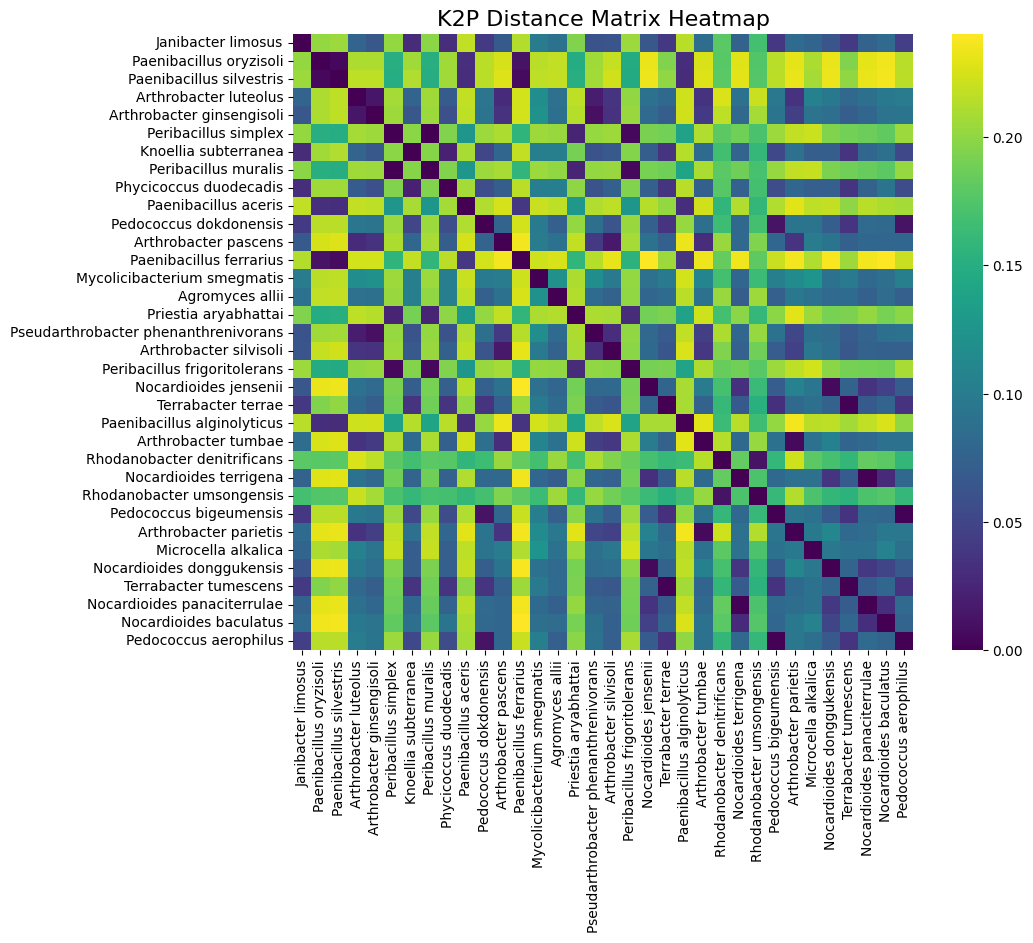

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(pairwise_distances_df, 
            # annot=True, 
            fmt=".3f", 
            cmap="viridis", 
            xticklabels=pairwise_distances_df.columns, 
            yticklabels=pairwise_distances_df.index)

plt.title("K2P Distance Matrix Heatmap", fontsize=16)
# plt.xlabel("Sequences")
# plt.ylabel("Sequences")
# plt.tight_layout()
plt.show()

In [16]:
parsed_organisms_path = "/tamir2/moranb/microbiome/Igem_TAU_2021/analysis/example_data/arabidopsis/arabidopsis_microbiome_processed"

data = []
organism_names = []

# Iterate over files in the given directory
for filename in os.listdir(parsed_organisms_path):
    if filename.endswith('.json'):
        filepath = os.path.join(parsed_organisms_path, filename)
        with open(filepath, 'r') as f:
            content = json.load(f)
        # extract cai_weights dict
        cai_weights = content.get("cai_weights", {})
        data.append(cai_weights)
        organism_names.append(os.path.splitext(filename)[0])

# Create DataFrame: rows = organisms, columns = codons
arabidopsis_cai_weights = pd.DataFrame(data, index=organism_names)


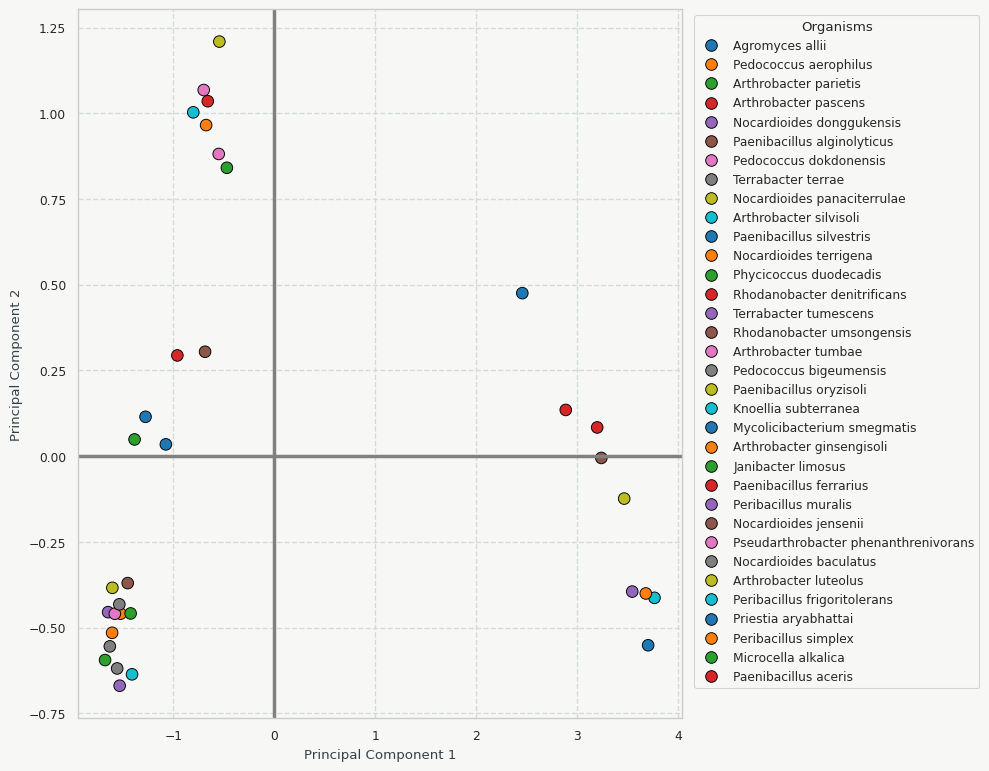

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Assume df is your dataframe: rows = organisms, columns = CAI weights, index = organism names
df = arabidopsis_cai_weights
# PCA transformation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.values)

# Prepare DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'organism': df.index
})

# Color definitions
bg_color = '#f7f8f5'

sns.set(style="whitegrid", context="paper") 
plt.figure(figsize=(10,8))
ax = plt.gca()

# Set unified background for plot and legend
plt.gcf().patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Draw grid
ax.grid(True, which='both', color='#d4dadb', linestyle='--', linewidth=1)

# Draw bold x and y axes lines (centered at 0)
ax.axhline(0, color='grey', linewidth=2.5)  # bold y=0 line
ax.axvline(0, color='grey', linewidth=2.5)  # bold x=0 line

sns.scatterplot(
    data=pca_df,
    x='PC1', 
    y='PC2',
    s=70,
    edgecolor='black',
    hue='organism',
    palette='tab10',
    legend='full'
)

plt.xlabel("Principal Component 1", color='#324148')
plt.ylabel("Principal Component 2", color='#324148')
# plt.title("PCA of CAI Weights Across Organisms", fontweight='bold', fontsize=13 ,color='#324148')

# Customize legend to use same background
leg = plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    title='Organisms',
    frameon=True
)
frame = leg.get_frame()
frame.set_facecolor(bg_color)
frame.set_edgecolor('#cccccc')

plt.tight_layout()
plt.show()

In [19]:
# Assume df is your CAI weight matrix, rows=samples, columns=codons/features
clustering_mat = arabidopsis_cai_weights.values
n_samples = clustering_mat.shape[0]
cai_distance_matrix = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    sample_i = clustering_mat[i, :]
    for k in range(n_samples):
        sample_k = clustering_mat[k, :]
        corr, _ = stats.spearmanr(sample_k, sample_i)
        cai_distance_matrix[i, k] = 1 - corr  # distance = 1 - correlation

# If you want a DataFrame (with organism names as index and columns):
cai_distance_df = pd.DataFrame(
    cai_distance_matrix, 
    index=arabidopsis_cai_weights.index, 
    columns=arabidopsis_cai_weights.index
)

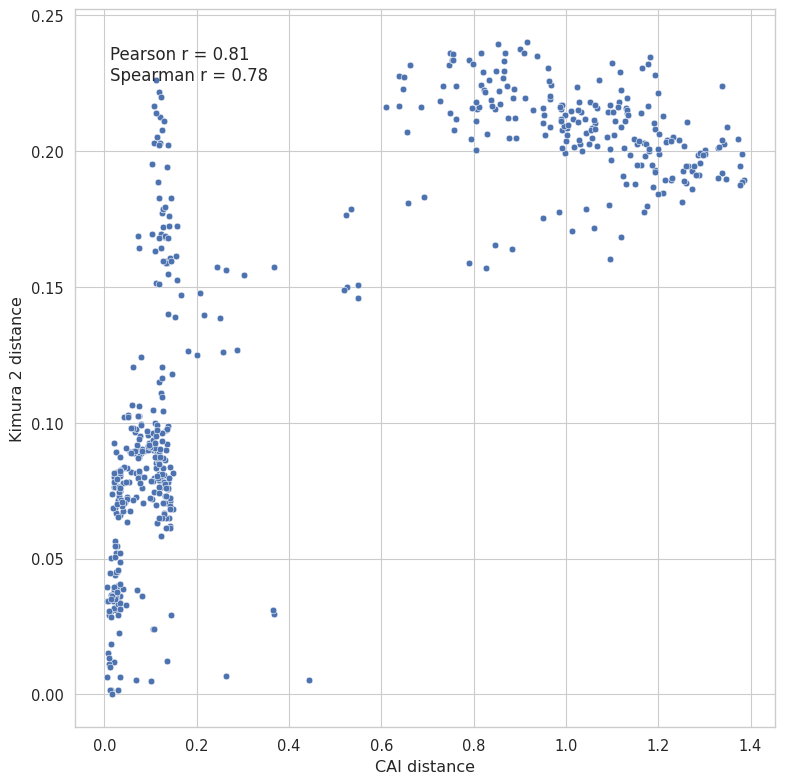

In [31]:
# Find intersection of organism names
common_orgs = cai_distance_df.index.intersection(pairwise_distances_df.index)

# Extract the submatrices for common orgs
d1 = cai_distance_df.loc[common_orgs, common_orgs]
d2 = pairwise_distances_df.loc[common_orgs, common_orgs]

# Use the upper triangle (excluding diagonal) for comparison, to avoid redundancy
triu_indices = np.triu_indices_from(d1, k=1)
d1_flat = d1.values[triu_indices]
d2_flat = d2.values[triu_indices]

# Plot scatter and compute Pearson correlation
plt.figure(figsize=(8, 8))
sns.scatterplot(x=d1_flat, y=d2_flat)
plt.xlabel('CAI distance')
plt.ylabel('Kimura 2 distance')
# plt.title('Correlation of Pairwise Distances of CAI Profiles and Kimura-2')

# Optional: compute and annotate Pearson/Spearman correlation
pear_corr, p_val = stats.pearsonr(d1_flat, d2_flat)
spear_corr, _ = stats.spearmanr(d1_flat, d2_flat)
plt.annotate(f"Pearson r = {pear_corr:.2f}\nSpearman r = {spear_corr:.2f}", (0.05, 0.95), 
             xycoords='axes fraction', ha='left', va='top', fontsize=12)

plt.tight_layout()
plt.show()


### Pairwise

In [20]:
pairwise_result_path = "analysis/results/arabidopsis/processed/pairwise.pkl"
# res, errors = get_scores_df_by_configuration_df("pairwise")
# res.to_pickle(pairwise_result_path)
res = pd.read_pickle(pairwise_result_path)
res

,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,final_optimization_score_single_wanted_organism,average_distance_score_single_wanted_organism,average_distance_non_normalized_score_single_wanted_organism,weakest_link_score_single_wanted_organism,ratio_score_single_wanted_organism,orf_optimization_cub_index_single_wanted_organism,evaluation_score_single_wanted_organism,run_time_single_wanted_organism,iterations_count_single_wanted_organism,final_sequence_single_wanted_organism
0,Agromyces allii,Arthrobacter luteolus,0.822131,1.049206,1.194508,0.165263,1.194508,1.140862,CAI,average_distance,...,None,0.762162,0.135175,0.762162,1.077175,CAI,average_distance,0.000531,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
1,Agromyces allii,Nocardioides panaciterrulae,1.124537,1.073376,0.893233,0.075484,0.893233,1.163930,CAI,average_distance,...,None,0.310010,0.006800,0.310010,1.032277,CAI,average_distance,0.000383,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
2,Agromyces allii,Nocardioides donggukensis,1.223519,1.076886,0.606917,0.074928,0.606917,1.102914,CAI,average_distance,...,None,-0.355985,-0.002917,-0.355985,0.966427,CAI,average_distance,0.000537,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
3,Agromyces allii,Nocardioides jensenii,0.811392,1.015025,0.599594,0.047381,0.599594,1.078668,CAI,average_distance,...,None,0.351911,0.019506,0.351911,1.036362,CAI,average_distance,0.000501,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
4,Agromyces allii,Paenibacillus oryzisoli,0.734763,1.188781,7.686056,0.590208,7.686056,3.773800,CAI,average_distance,...,None,7.722124,0.610278,7.722124,3.058654,CAI,average_distance,0.000403,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,Mycolicibacterium smegmatis,Pedococcus aerophilus,1.012050,1.132195,1.816729,0.139412,1.816729,1.493486,CAI,average_distance,...,None,0.410001,-0.033106,0.410001,1.038470,CAI,average_distance,0.001270,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
1118,Mycolicibacterium smegmatis,Nocardioides terrigena,1.033338,1.116769,1.983707,0.108151,1.983707,1.319059,CAI,average_distance,...,None,0.819605,-0.049728,0.819605,1.081707,CAI,average_distance,0.000370,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
1119,Mycolicibacterium smegmatis,Pedococcus bigeumensis,1.026813,1.120494,1.661116,0.123258,1.661116,1.401582,CAI,average_distance,...,None,0.287010,-0.043225,0.287010,1.026467,CAI,average_distance,0.001272,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
1120,Mycolicibacterium smegmatis,Terrabacter terrae,0.869869,1.119769,2.000921,0.131590,2.000921,1.414678,CAI,average_distance,...,None,0.853849,-0.038140,0.853849,1.085571,CAI,average_distance,0.000371,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...


In [21]:
res["organism_distance"] = res.apply(lambda row: pairwise_distances_df[row.wanted_organisms][row.unwanted_organisms], axis=1)

In [32]:
score_type = "average_distance_score"
variant_type = "zscore_bulk_ratio"
score = f"{score_type}_{variant_type}"
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(data=res[[score, "organism_distance"]],  x="organism_distance", y=score)
r, p = stats.spearmanr(res["organism_distance"], res[score])
plt.xlabel('Kimura 2 distance')
plt.ylabel('average distance score')
plt.annotate(f"Spearman r = {r}", (0.05, 0.95), 
             xycoords='axes fraction', ha='left', va='top', fontsize=10)
print(r, p)      


KeyError: "['organism_distance'] not in index"

<Figure size 1000x800 with 0 Axes>

   percentile  average_distance_score_zscore_bulk_ratio
0           0                                  0.771382
1           1                                  0.775222
2           2                                  1.041669
3           3                                  1.134908
4           4                                  1.543851
5           5                                  2.767337
6           6                                  5.115353
7           7                                  4.869247
8           8                                  4.879957
9           9                                  4.716139


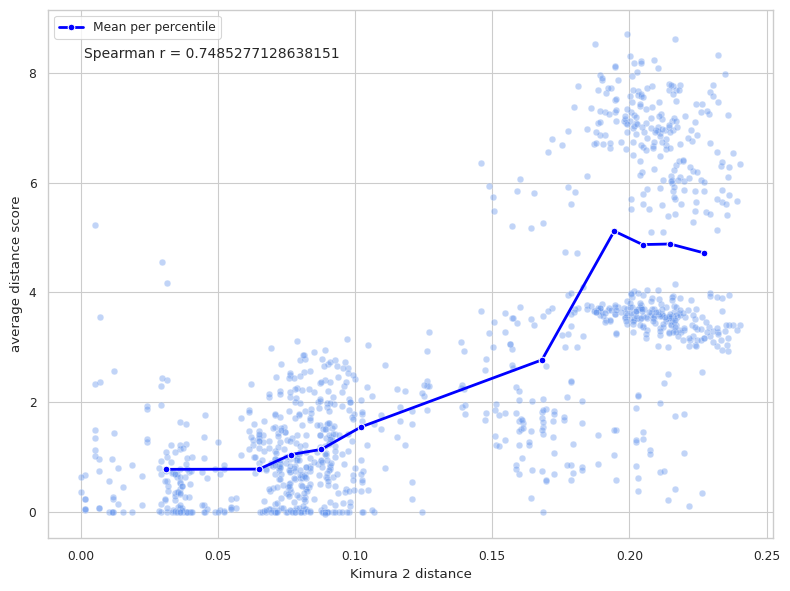

In [23]:
score_type = "average_distance_score"
variant_type = "zscore_bulk_ratio"
score = f"{score_type}_{variant_type}"
res['percentile'] = pd.qcut(res['organism_distance'], q=10, labels=False)

mean_scores = res.groupby('percentile')[score].mean().reset_index()
print(mean_scores)
bin_centers = res.groupby('percentile')['organism_distance'].median().values

plt.figure(figsize=(8,6))
r, p = stats.spearmanr(res["organism_distance"], res[score])
# Scatter plot of all data points
sns.scatterplot(
    x='organism_distance',
    y=score,
    data=res,
    alpha=0.4,
    color="cornflowerblue"
)

# Overlay the mean per percentile as a line plot
sns.lineplot(
    x=bin_centers,
    y=mean_scores[score],
    marker='o',
    color='blue',
    linewidth=2,
    label='Mean per percentile'
)
plt.annotate(f"Spearman r = {r}", (0.05, 0.93), 
             xycoords='axes fraction', ha='left', va='top', fontsize=10)
plt.xlabel('Kimura 2 distance')
plt.ylabel('average distance score')
plt.legend()
plt.tight_layout()
plt.show()

### One vs All

In [37]:
one_vs_all_result_path = "analysis/results/arabidopsis/processed/one_vs_all.pkl"
# res, errors = get_scores_df_by_configuration_df("one_vs_all")
# res.to_pickle(one_vs_all_result_path)
one_vs_all = pd.read_pickle(one_vs_all_result_path)
one_vs_all

,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,final_optimization_score_single_wanted_organism,average_distance_score_single_wanted_organism,average_distance_non_normalized_score_single_wanted_organism,weakest_link_score_single_wanted_organism,ratio_score_single_wanted_organism,orf_optimization_cub_index_single_wanted_organism,evaluation_score_single_wanted_organism,run_time_single_wanted_organism,iterations_count_single_wanted_organism,final_sequence_single_wanted_organism
0,Nocardioides panaciterrulae,Agromyces allii|Arthrobacter ginsengisoli|Arth...,0.906502,1.028778,2.099949,0.191450,4.090678,1.312988,CAI,average_distance,...,None,1.931974,0.193616,4.469035,1.220567,CAI,average_distance,0.000388,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
1,Nocardioides jensenii,Agromyces allii|Arthrobacter ginsengisoli|Arth...,0.950714,1.040290,1.991924,0.172161,3.985830,1.304489,CAI,average_distance,...,None,1.758532,0.166947,4.300694,1.208427,CAI,average_distance,0.001355,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
2,Paenibacillus aceris,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.170481,1.141776,2.943816,0.130340,3.407749,1.289050,CAI,average_distance,...,None,2.965514,0.128189,3.500986,1.286517,CAI,average_distance,0.001406,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
3,Rhodanobacter denitrificans,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.018159,1.053115,1.139129,0.173545,2.087908,1.155025,CAI,average_distance,...,None,0.771100,0.172585,3.106586,1.139645,CAI,average_distance,0.001319,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
4,Nocardioides donggukensis,Agromyces allii|Arthrobacter ginsengisoli|Arth...,0.860789,1.036334,2.866097,0.210924,4.844499,1.371838,CAI,average_distance,...,None,2.618359,0.197552,5.032300,1.283366,CAI,average_distance,0.001409,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
5,Peribacillus frigoritolerans,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.156336,1.151132,3.288627,0.149003,3.407216,1.340945,CAI,average_distance,...,None,3.281450,0.146967,3.429129,1.337454,CAI,average_distance,0.001502,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
6,Paenibacillus alginolyticus,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.175510,1.140420,2.826124,0.118182,3.434524,1.271851,CAI,average_distance,...,None,2.826124,0.118182,3.434524,1.271851,CAI,average_distance,0.001285,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
7,Paenibacillus ferrarius,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.161218,1.134982,2.755769,0.097560,3.244086,1.266882,CAI,average_distance,...,None,2.717673,0.089108,3.395422,1.256188,CAI,average_distance,0.001423,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
8,Peribacillus muralis,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.118195,1.142098,2.997208,0.157940,3.464043,1.294966,CAI,average_distance,...,None,2.976447,0.153375,3.535593,1.287416,CAI,average_distance,0.000462,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
9,Pedococcus aerophilus,Agromyces allii|Arthrobacter ginsengisoli|Arth...,0.919187,1.036685,2.267909,0.188863,4.505976,1.297628,CAI,average_distance,...,None,2.256092,0.192942,4.626077,1.270805,CAI,average_distance,0.001375,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...


### Cluster vs All

In [35]:
cluster_vs_all_result_path = "analysis/results/arabidopsis/processed/cluster_vs_all.pkl"
res, errors = get_scores_df_by_configuration_df("cluster_vs_all")
res.to_pickle(cluster_vs_all_result_path)
cluster_vs_all = pd.read_pickle(cluster_vs_all_result_path)
cluster_vs_all

results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/cluster_vs_all/zscore_bulk_aa_ratio
found 5 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/cluster_vs_all/zscore_bulk_aa_diff
found 5 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/cluster_vs_all/single_codon_ratio
found 4 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/cluster_vs_all/single_codon_diff
found 7 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/cluster_vs_all/single_wanted_organism
found 34 files


,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,final_optimization_score_single_wanted_organism,average_distance_score_single_wanted_organism,average_distance_non_normalized_score_single_wanted_organism,weakest_link_score_single_wanted_organism,ratio_score_single_wanted_organism,orf_optimization_cub_index_single_wanted_organism,evaluation_score_single_wanted_organism,run_time_single_wanted_organism,iterations_count_single_wanted_organism,final_sequence_single_wanted_organism
0,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,None,2.447100,0.098220,0.150288,1.241316,CAI,average_distance,0.012670,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
1,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,None,2.671058,0.109378,0.217069,1.265436,CAI,average_distance,0.004996,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
2,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,None,2.501188,0.090980,0.277077,1.242031,CAI,average_distance,0.000847,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
3,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,None,0.661830,-0.023414,-0.134683,1.052904,CAI,average_distance,0.016898,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...
4,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,None,2.447100,0.098220,0.150288,1.241316,CAI,average_distance,0.000631,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,None,5.753576,0.454180,-0.163696,2.020064,CAI,average_distance,0.000692,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
63,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,None,5.753576,0.454180,-0.163696,2.020064,CAI,average_distance,0.000987,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
64,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,None,5.803926,0.456016,-0.158154,2.058106,CAI,average_distance,0.012154,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
65,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,None,5.194949,0.426615,-0.218334,1.748764,CAI,average_distance,0.001531,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...


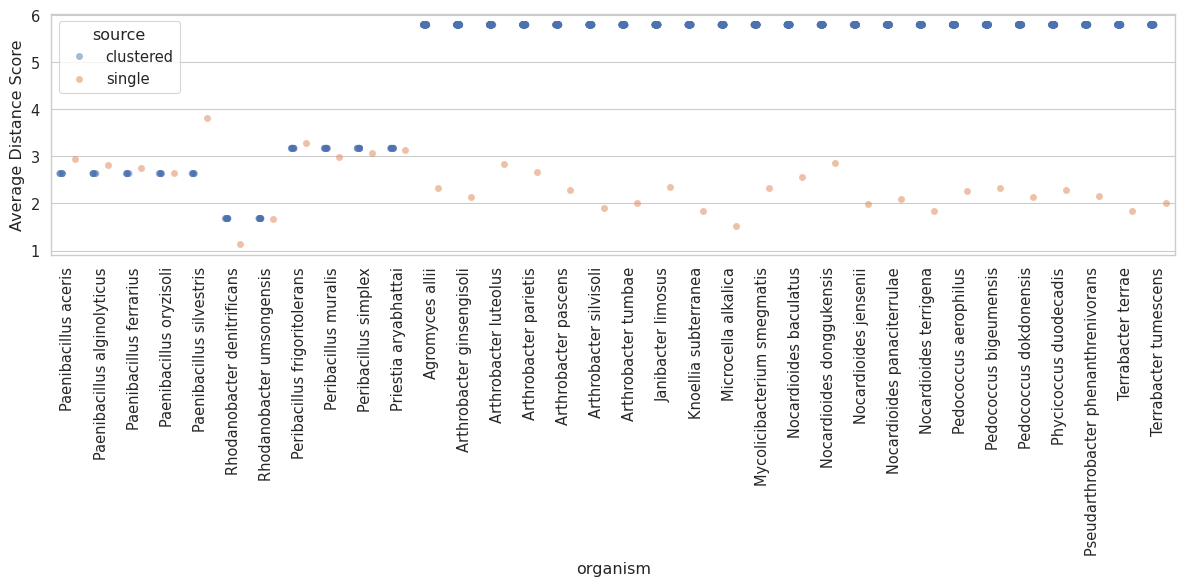

In [38]:
cluster_expanded = (
    cluster_vs_all
    .assign(wanted_list=lambda x: x["wanted_organisms"].str.split("|"))
    .explode("wanted_list")
    .rename(columns={"wanted_list": "organism"})
)

# In df_single, the wanted organism is already single
single_expanded = one_vs_all.rename(columns={"wanted_organisms": "organism"})

# --- 2. Extract the average_distance_score columns ---
col_name = "average_distance_score_zscore_bulk_ratio"

plot_multi = cluster_expanded[["organism", col_name]].assign(source="clustered")
plot_single = single_expanded[["organism", col_name]].assign(source="single")

# --- 3. Combine for plotting ---
df_plot = pd.concat([plot_multi, plot_single], ignore_index=True)

# --- 4. Make the seaborn plot ---
plt.figure(figsize=(12, 6))
# sns.boxplot(
#     data=df_plot,
#     x="organism",
#     y=col_name,
#     hue="source"
# )
sns.stripplot(
    data=df_plot,
    x="organism",
    y=col_name,
    hue="source",
    dodge=True,
    alpha=0.5,
)

plt.xticks(rotation=90)
plt.ylabel("Average Distance Score")
plt.tight_layout()
plt.show()

In [39]:
cluster_distances = pd.read_pickle("analysis/results/arabidopsis/processed/cluster_distances.pkl")
cluster_distances

,cluster_id,intra_cluster_dist,inter_cluster_dist
Janibacter limosus,1,0.063147,0.199531
Paenibacillus oryzisoli,4,0.020273,0.204399
Paenibacillus silvestris,4,0.018164,0.206183
Arthrobacter luteolus,1,0.073237,0.215339
Arthrobacter ginsengisoli,1,0.068236,0.21288
Peribacillus simplex,3,0.009747,0.189662
Knoellia subterranea,1,0.066212,0.197059
Peribacillus muralis,3,0.00968,0.188667
Phycicoccus duodecadis,1,0.065411,0.198134
Paenibacillus aceris,4,0.033531,0.198164


In [40]:
organism_clusters = []
for cluster_id in sorted(cluster_distances["cluster_id"].dropna().unique()):
    cluster_orgs = cluster_distances.loc[
        cluster_distances["cluster_id"] == cluster_id
    ].index.tolist()
    organism_clusters.append(cluster_orgs)

cluster_vs_all["first_org"] = cluster_vs_all["wanted_organisms"].str.split("|").str[0]

# Map first_org → cluster_id directly
cluster_vs_all["cluster_id"] = cluster_vs_all["first_org"].map(
    dict(zip(cluster_distances.index, cluster_distances["cluster_id"]))
)

# Aggregate distances by cluster_id and merge
cluster_distances_agg = (
    cluster_distances.groupby("cluster_id")[["intra_cluster_dist", "inter_cluster_dist"]]
    .mean()
    .reset_index()
)

cluster_vs_all_enhanced = pd.merge(
    cluster_vs_all,
    cluster_distances_agg,
    on="cluster_id",
    how="left"
)

cluster_vs_all_enhanced["intra_inter_ratio"] = (
    cluster_vs_all_enhanced["intra_cluster_dist"] / 
    cluster_vs_all_enhanced["inter_cluster_dist"]
)

print("✅ Perfect 100% merge - cluster_id directly matches!")
cluster_vs_all_enhanced

# cluster_vs_all_enhanced.to_pickle("analysis/results/arabidopsis/processed/cluster_vs_all_enhanced.pkl")
# print("cluster_vs_all_enhanced saved!")
# cluster_vs_all_enhanced

✅ Perfect 100% merge - cluster_id directly matches!


,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,orf_optimization_cub_index_single_wanted_organism,evaluation_score_single_wanted_organism,run_time_single_wanted_organism,iterations_count_single_wanted_organism,final_sequence_single_wanted_organism,first_org,cluster_id,intra_cluster_dist,inter_cluster_dist,intra_inter_ratio
0,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,CAI,average_distance,0.012670,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515
1,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,CAI,average_distance,0.004996,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515
2,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,CAI,average_distance,0.000847,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515
3,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,CAI,average_distance,0.016898,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...,Paenibacillus aceris,4,0.025491,0.204726,0.124515
4,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,CAI,average_distance,0.000631,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,CAI,average_distance,0.000692,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103
63,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,CAI,average_distance,0.000987,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103
64,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,CAI,average_distance,0.012154,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103
65,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,CAI,average_distance,0.001531,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103


In [41]:
# ---- 3. Join to one_vs_all (per-organism) ----
# Extract organism name from wanted_organisms (single organism per row)
one_vs_all["organism"] = one_vs_all["wanted_organisms"]  # already single names!

one_vs_all_enhanced = pd.merge(
    one_vs_all,
    cluster_distances,
    left_on="organism",  # or "wanted_organisms" if that's your column name
    right_index=True,
    how="left"
)

one_vs_all_enhanced.to_pickle("analysis/results/arabidopsis/processed/one_vs_all_enhanced.pkl")
print("one_vs_all_enhanced saved!")

one_vs_all_enhanced saved!


In [48]:
sns.set(style="whitegrid", context="paper", font_scale=1.2)

# ---- Data prep (unchanged) ----
cluster_expanded = (
    cluster_vs_all_enhanced.assign(wanted_list=lambda x: x["wanted_organisms"].str.split("|"))
    .explode("wanted_list").rename(columns={"wanted_list": "organism"})
)
single_expanded = one_vs_all_enhanced.rename(columns={"wanted_organisms": "organism"})
score_col = "average_distance_score_zscore_bulk_diff"
inter_col, intra_col = "inter_cluster_dist", "intra_cluster_dist"

df_cluster_summary = cluster_vs_all_enhanced.copy()
df_cluster_summary["cluster_label"] = df_cluster_summary["wanted_organisms"].str.split("|").str[0]
df_cluster_summary
# print(df_cluster_summary)

,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,evaluation_score_single_wanted_organism,run_time_single_wanted_organism,iterations_count_single_wanted_organism,final_sequence_single_wanted_organism,first_org,cluster_id,intra_cluster_dist,inter_cluster_dist,intra_inter_ratio,cluster_label
0,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,average_distance,0.012670,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515,Paenibacillus aceris
1,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,average_distance,0.004996,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515,Paenibacillus aceris
2,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,average_distance,0.000847,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515,Paenibacillus aceris
3,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,average_distance,0.016898,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...,Paenibacillus aceris,4,0.025491,0.204726,0.124515,Paenibacillus aceris
4,Paenibacillus aceris|Paenibacillus alginolytic...,Agromyces allii|Arthrobacter ginsengisoli|Arth...,1.192104,1.143651,2.635002,0.115678,0.217868,1.272985,CAI,average_distance,...,average_distance,0.000631,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Paenibacillus aceris,4,0.025491,0.204726,0.124515,Paenibacillus aceris
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,average_distance,0.000692,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103,Agromyces allii
63,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,average_distance,0.000987,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103,Agromyces allii
64,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,average_distance,0.012154,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103,Agromyces allii
65,Agromyces allii|Arthrobacter ginsengisoli|Arth...,Paenibacillus aceris|Paenibacillus alginolytic...,0.838820,1.113464,5.797020,0.446367,-0.142850,2.190590,CAI,average_distance,...,average_distance,0.001531,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,Agromyces allii,1,0.071883,0.205318,0.350103,Agromyces allii


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


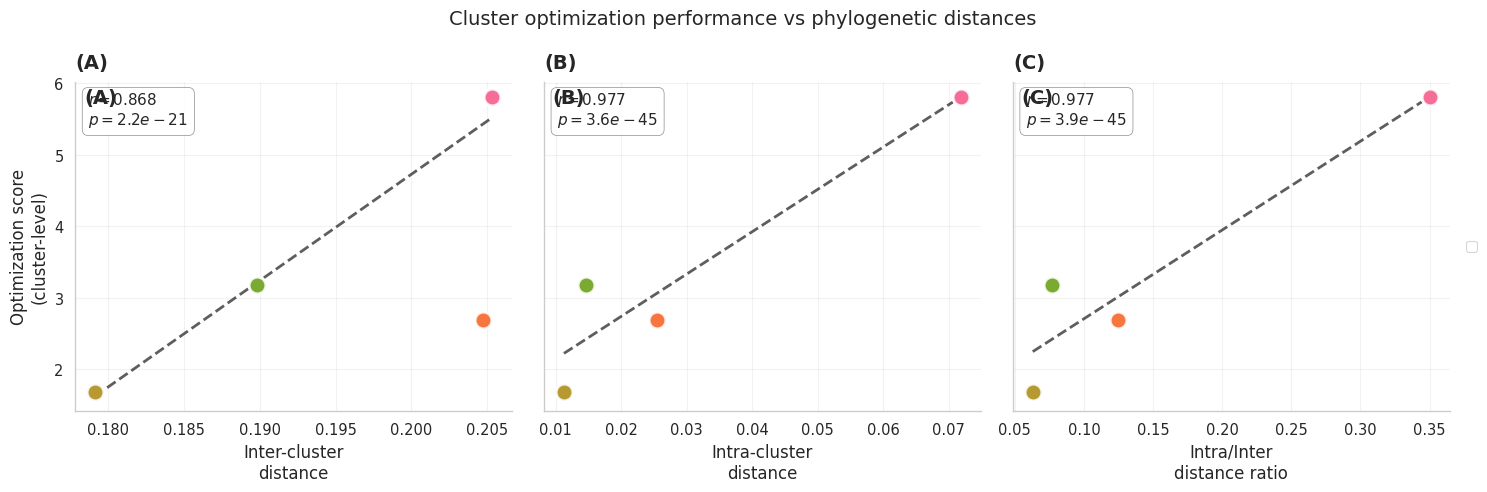

In [49]:
df_melt = df_cluster_summary.melt(
    id_vars=[score_col],
    value_vars=[inter_col, intra_col, "intra_inter_ratio"],
    var_name="distance_type",
    value_name="distance_value"
)
# print(df_melt) 
distance_label_map = {
    inter_col: "Inter-cluster\ndistance", 
    intra_col: "Intra-cluster\ndistance", 
    "intra_inter_ratio": "Intra/Inter\ndistance ratio"
}
df_melt["distance_type"] = df_melt["distance_type"].map(distance_label_map)

# ---- FIXED FIGURE: Safe numeric handling ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Cluster optimization performance vs phylogenetic distances", fontsize=14, y=0.98)

colors = sns.color_palette("husl", n_colors=len(df_cluster_summary))
distance_types = df_melt["distance_type"].unique()

for i, dist_type in enumerate(distance_types):
    ax = axes[i]
    subset = df_melt[df_melt["distance_type"] == dist_type]
    
    # Scatter each cluster individually
    for j, (_, row) in enumerate(df_cluster_summary.iterrows()):
        x_val = row[[inter_col, intra_col, "intra_inter_ratio"]].get(
            [k for k in distance_label_map.keys() if distance_label_map[k] == dist_type][0], 
            np.nan
        )
        y_val = row[score_col]
        
        if pd.notna(x_val) and pd.notna(y_val):
            ax.scatter(x_val, y_val, s=140, alpha=0.85, color=colors[j], 
                      edgecolor="white", linewidth=1.8, zorder=3,
                      label=row["cluster_label"] if i == 0 else "")

    # FIXED: Safe correlation + trend line
    x_numeric = pd.to_numeric(subset["distance_value"], errors="coerce")
    y_numeric = pd.to_numeric(subset[score_col], errors="coerce")
    
    valid_mask = ~(x_numeric.isna() | y_numeric.isna())
    if valid_mask.sum() >= 2:
        x_clean, y_clean = x_numeric[valid_mask], y_numeric[valid_mask]
        
        # Pearson correlation
        pearson_r, pearson_p = stats.pearsonr(x_clean, y_clean)
        
        # Trend line
        trend = np.polyfit(x_clean, y_clean, 1)
        x_trend = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_trend, np.polyval(trend, x_trend), "k--", alpha=0.7, lw=2, zorder=2)
        
        # Stats box
        stats_text = f"$r={pearson_r:.3f}$\n$p={pearson_p:.1e}$"
        ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, 
                va="top", ha="left", fontsize=11, weight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9,
                         edgecolor="gray", linewidth=0.5))

    ax.set_xlabel(dist_type, fontsize=12)
    ax.set_title(f"({chr(65+i)})", loc="left", fontsize=14, weight="bold", pad=10)
    ax.grid(True, alpha=0.25, zorder=0)
    sns.despine(ax=ax)
    
    # Letter labels (A, B, C)
    ax.text(0.02, 0.98, f"({chr(65+i)})", transform=ax.transAxes, 
            fontsize=14, weight="bold", va="top")

axes[0].set_ylabel("Optimization score\n(cluster-level)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.savefig("cluster_distance_correlations.pdf", dpi=300, bbox_inches="tight")
plt.show()

cluster_expanded shape: (1131, 3)
single_expanded shape: (34, 3)

Sample cluster_expanded:
                      organism  average_distance_score_zscore_bulk_ratio  \
0         Paenibacillus aceris                                  2.635002   
0  Paenibacillus alginolyticus                                  2.635002   
0      Paenibacillus ferrarius                                  2.635002   
0      Paenibacillus oryzisoli                                  2.635002   
0     Paenibacillus silvestris                                  2.635002   

    source  
0  Cluster  
0  Cluster  
0  Cluster  
0  Cluster  
0  Cluster  

Sample single_expanded:
                      organism  average_distance_score_zscore_bulk_ratio  \
0  Nocardioides panaciterrulae                                  2.099949   
1        Nocardioides jensenii                                  1.991924   
2         Paenibacillus aceris                                  2.943816   
3  Rhodanobacter denitrificans               

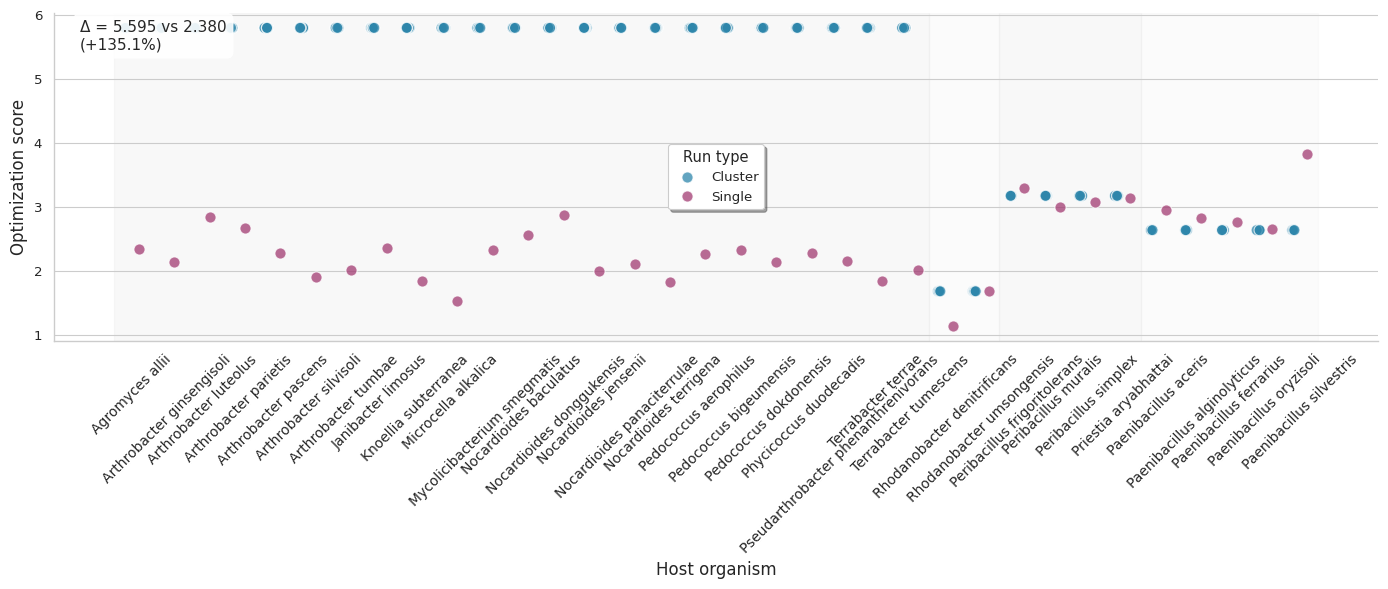

In [60]:
# From your enhanced dataframes
score_col = "average_distance_score_zscore_bulk_ratio"

# CLUSTER EXPANDED: one row per organism within each cluster run
cluster_expanded = (
    cluster_vs_all_enhanced
    .assign(wanted_list=lambda x: x["wanted_organisms"].str.split("|"))
    .explode("wanted_list")
    .rename(columns={"wanted_list": "organism"})
    [["organism", score_col]]  # Clean: just organism + score
    .assign(source="Cluster")   # Add source label
)

# SINGLE EXPANDED: one row per single-organism run
single_expanded = (
    one_vs_all_enhanced
    [["wanted_organisms", score_col]]  # Use original wanted_organisms column
    .rename(columns={"wanted_organisms": "organism"})
    .assign(source="Single")           # Add source label
)

print("cluster_expanded shape:", cluster_expanded.shape)
print("single_expanded shape:", single_expanded.shape)
print("\nSample cluster_expanded:")
print(cluster_expanded.head())
print("\nSample single_expanded:")
print(single_expanded.head())

# ---- GRAPH 2: Cluster vs Single per organism, grouped by cluster ----
sns.set(style="whitegrid", context="paper", font_scale=1.1)

# YOUR UPDATED CODE (unchanged)
organism_to_cluster = {}
for cid, cluster in enumerate(organism_clusters, start=1):
    for org in cluster:
        organism_to_cluster[org] = f"Cluster {cid}"

cluster_expanded["cluster_id"] = cluster_expanded["organism"].map(organism_to_cluster)
single_expanded["cluster_id"] = single_expanded["organism"].map(organism_to_cluster)

plot_cluster = cluster_expanded[["organism", "cluster_id", score_col]].assign(source="Cluster")
plot_single = single_expanded[["organism", "cluster_id", score_col]].assign(source="Single")

df_plot = pd.concat([plot_cluster, plot_single], ignore_index=True)

# Order organisms by cluster
cluster_order = sorted(df_plot["cluster_id"].dropna().unique())
organism_order = []
for cid in cluster_order:
    orgs = sorted(df_plot.loc[df_plot["cluster_id"] == cid, "organism"].dropna().unique())
    organism_order.extend(orgs)

# REFINED PUBLICATION FIGURE
fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(
    data=df_plot,
    x="organism",
    y=score_col,
    hue="source",
    dodge=True,
    size=8,
    alpha=0.75,
    order=organism_order,
    palette={"Cluster": "#2E86AB", "Single": "#A23B72"},
    edgecolor="white",
    linewidth=0.8
)

# Cluster grouping shading
for i, cid in enumerate(cluster_order):
    orgs = [o for o in organism_order if organism_to_cluster.get(o) == cid]
    if orgs:
        start = organism_order.index(orgs[0]) - 0.5
        end = organism_order.index(orgs[-1]) + 0.5
        ax.axvspan(start, end, color="lightgrey", alpha=0.15 if i%2==0 else 0.08, zorder=0)

ax.set_xlabel("Host organism", fontsize=12)
ax.set_ylabel("Optimization score", fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.legend(title="Run type", frameon=True, fancybox=True, shadow=True)

# Stats: mean difference
mean_cluster = df_plot[df_plot["source"]=="Cluster"][score_col].mean()
mean_single = df_plot[df_plot["source"]=="Single"][score_col].mean()
diff_pct = 100 * (mean_cluster - mean_single) / mean_single
ax.text(0.02, 0.98, f"Δ = {mean_cluster:.3f} vs {mean_single:.3f}\n({diff_pct:+.1f}%)", 
        transform=ax.transAxes, va="top", ha="left", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

sns.despine()
plt.tight_layout()
plt.savefig("graph2_cluster_vs_single.pdf", dpi=300, bbox_inches="tight")
plt.show()


   cluster_id  cluster_score  single_mean_score  single_median_score  n_single
0           1       5.797020           2.199928             2.151835        23
1           2       1.679209           1.408753             1.408753         2
2           3       3.171474           3.123008             3.103098         4
3           4       2.635002           2.999213             2.826124         5


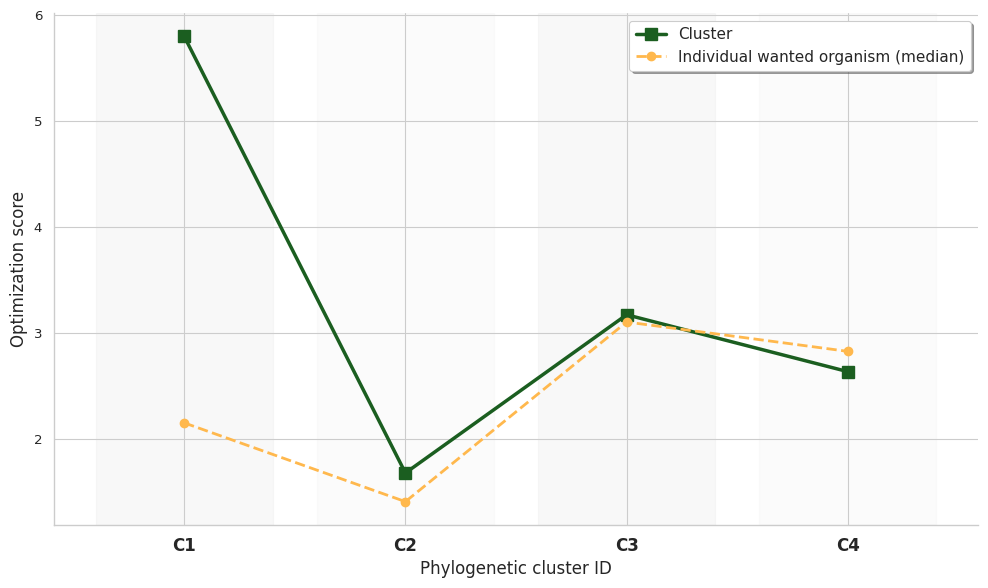

Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB


In [83]:
SCORE_COL = "average_distance_score_zscore_bulk_ratio"

# 0) Build organism_to_cluster as before (numeric ids)
organism_to_cluster = {}
for cid, cluster in enumerate(organism_clusters, start=1):
    for org in cluster:
        organism_to_cluster[org] = cid

# 1) Single scores: all single-run scores, with cluster_id attached
single_expanded = (
    one_vs_all_enhanced[[SCORE_COL, "wanted_organisms"]]  # all single runs
    .rename(columns={"wanted_organisms": "organism"})
)
single_expanded["cluster_id"] = single_expanded["organism"].map(organism_to_cluster)

# Keep only organisms in defined clusters
single_expanded = single_expanded.dropna(subset=["cluster_id", SCORE_COL])

# 2) Cluster scores: per-organism score derived from cluster run
cluster_scores = (
    cluster_vs_all_enhanced[[SCORE_COL, "wanted_organisms"]]
    .assign(organism=lambda x: x["wanted_organisms"].str.split("|").str[0])
    .rename(columns={SCORE_COL: "cluster_score"})[["organism", "cluster_score"]]
)

# Attach cluster_id to cluster scores too
cluster_scores["cluster_id"] = cluster_scores["organism"].map(organism_to_cluster)
cluster_scores = cluster_scores.dropna(subset=["cluster_id"])

# Cluster-level mean and median of single scores (pooled within cluster)
single_cluster_summary = (
    single_expanded
    .groupby("cluster_id")[SCORE_COL]
    .agg(single_mean_score="mean",
         single_median_score="median",
         n_single="count")
    .reset_index()
)

# Cluster-level cluster score (if only one run per cluster, mean == that score)
cluster_summary_score = (
    cluster_scores
    .groupby("cluster_id")["cluster_score"]
    .mean()   # in case multiple rows per cluster_id
    .reset_index()
)

# Merge to get one row per cluster
cluster_summary = (
    cluster_summary_score
    .merge(single_cluster_summary, on="cluster_id", how="inner")
)

print(cluster_summary)

cluster_order = sorted(cluster_summary["cluster_id"].unique())
x_pos = np.arange(len(cluster_order))

fig, ax = plt.subplots(figsize=(10, 6))

# Cluster score line
ax.plot(
    x_pos,
    cluster_summary.set_index("cluster_id").loc[cluster_order, "cluster_score"],
    "s-",
    color="#1B5E20",
    linewidth=2.5,
    markersize=8,
    label="Cluster"
)

# Mean single line
# ax.plot(
#     x_pos,
#     cluster_summary.set_index("cluster_id").loc[cluster_order, "single_mean_score"],
#     "o-",
#     color="#FF9500",
#     linewidth=2.5,
#     markersize=8,
#     label="Mean single"
# )

# Median single line
ax.plot(
    x_pos,
    cluster_summary.set_index("cluster_id").loc[cluster_order, "single_median_score"],
    "o--",
    color="#FFB84D",
    linewidth=2.0,
    markersize=6,
    label="Individual wanted organism (median)"
)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"C{cid}" for cid in cluster_order], fontsize=12, fontweight="bold")

for i, cid in enumerate(cluster_order):
    ax.axvspan(i - 0.4, i + 0.4, color="lightgrey", alpha=0.15 if i % 2 == 0 else 0.08)

ax.set_xlabel("Phylogenetic cluster ID", fontsize=12)
ax.set_ylabel("Optimization score", fontsize=12)
ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig("graph3_cluster_vs_single_mean_median_pooled.pdf", dpi=300, bbox_inches="tight")
plt.show()


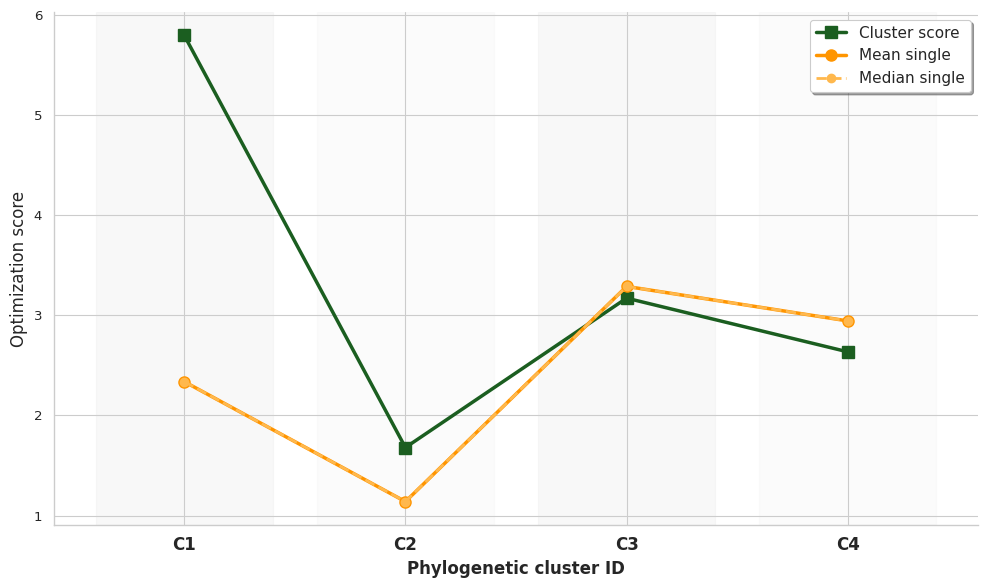

In [70]:
SCORE_COL = "average_distance_score_zscore_bulk_ratio"

cluster_summary = (
    df_comparison
    .groupby("cluster_id")
    .agg(
        cluster_score=("cluster_score", "mean"),            # cluster line
        single_mean_score=("single_mean_score", "mean"),    # mean single line
        single_median_score=("single_mean_score", "median") # median single line
    )
    .reset_index()
)

cluster_order = sorted(cluster_summary["cluster_id"].unique())
x_pos = np.arange(len(cluster_order))

fig, ax = plt.subplots(figsize=(10, 6))

# 1) Cluster score line (no mean/median wording)
ax.plot(
    x_pos,
    cluster_summary["cluster_score"],
    "s-",
    color="#1B5E20",
    linewidth=2.5,
    markersize=8,
    label="Cluster score"
)

# 2) Mean single line
ax.plot(
    x_pos,
    cluster_summary["single_mean_score"],
    "o-",
    color="#FF9500",
    linewidth=2.5,
    markersize=8,
    label="Mean single"
)

# 3) Median single line
ax.plot(
    x_pos,
    cluster_summary["single_median_score"],
    "o--",
    color="#FFB84D",
    linewidth=2.0,
    markersize=6,
    label="Median single"
)

# X-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels([f"C{cid}" for cid in cluster_order], fontsize=12, fontweight="bold")

# Optional: cluster shading
for i, cid in enumerate(cluster_order):
    ax.axvspan(i - 0.4, i + 0.4, color="lightgrey", alpha=0.15 if i % 2 == 0 else 0.08)

ax.set_xlabel("Phylogenetic cluster ID", fontsize=12, fontweight="bold")
ax.set_ylabel("Optimization score", fontsize=12)

ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig("graph3_cluster_mean_median_single_lines.pdf", dpi=300, bbox_inches="tight")
plt.show()


### Different Sizes

In [27]:
random_splits_results_path = "analysis/results/arabidopsis/processed/size_splits.pkl"
res, errors = get_scores_df_by_configuration_df("different_set_sizes", include_single_organism=False)
res.to_pickle(random_splits_results_path)
# res = pd.read_pickle(cluster_vs_all_result_path)
res

results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/different_set_sizes/zscore_bulk_aa_ratio
found 50 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/different_set_sizes/zscore_bulk_aa_diff
found 50 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/different_set_sizes/single_codon_ratio
found 50 files
results dir is: /tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis/different_set_sizes/single_codon_diff
found 50 files


,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,final_optimization_score_single_diff,average_distance_score_single_diff,average_distance_non_normalized_score_single_diff,weakest_link_score_single_diff,ratio_score_single_diff,orf_optimization_cub_index_single_diff,evaluation_score_single_diff,run_time_single_diff,iterations_count_single_diff,final_sequence_single_diff
0,Microcella alkalica|Nocardioides baculatus,Knoellia subterranea|Mycolicibacterium smegmatis,0.926879,0.994062,0.003514,0.054114,-0.279997,0.998301,CAI,average_distance,...,None,-0.384788,0.000014,-0.486932,0.946765,CAI,average_distance,0.032607,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...
1,Rhodanobacter denitrificans,Knoellia subterranea,1.252174,1.122928,0.747582,0.114254,0.747582,1.348911,CAI,average_distance,...,None,0.605517,0.092684,0.605517,1.320499,CAI,average_distance,0.087911,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...
2,Nocardioides jensenii,Pseudarthrobacter phenanthrenivorans,0.802318,1.040211,1.083311,0.118286,1.083311,1.188680,CAI,average_distance,...,None,0.944173,0.104675,0.944173,1.160221,CAI,average_distance,0.115310,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
3,Nocardioides panaciterrulae,Pedococcus bigeumensis,0.870306,1.007013,0.202112,0.041243,0.202112,1.024935,CAI,average_distance,...,None,0.096714,0.026065,0.096714,1.014921,CAI,average_distance,0.755928,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...
4,Paenibacillus oryzisoli,Arthrobacter parietis,1.188261,1.196395,3.098400,0.160701,3.098400,1.366574,CAI,average_distance,...,None,2.773513,0.146870,2.773513,1.341846,CAI,average_distance,0.020047,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
5,Arthrobacter tumbae|Paenibacillus alginolyticus,Arthrobacter luteolus|Paenibacillus oryzisoli,1.016314,1.040592,0.618726,0.031969,-1.902001,1.127836,CAI,average_distance,...,None,0.341646,0.022810,-1.852535,1.072690,CAI,average_distance,0.023099,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
6,Paenibacillus ferrarius,Mycolicibacterium smegmatis,1.311952,1.205265,3.159721,0.126383,3.159721,1.332770,CAI,average_distance,...,None,2.650030,0.119307,2.650030,1.304521,CAI,average_distance,0.192696,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
7,Nocardioides donggukensis|Peribacillus muralis,Arthrobacter tumbae|Rhodanobacter denitrificans,0.996888,1.050730,1.772470,0.102722,0.032095,1.219604,CAI,average_distance,...,None,1.294678,0.071131,-0.028205,1.156892,CAI,average_distance,0.026439,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
8,Mycolicibacterium smegmatis|Priestia aryabhattai,Arthrobacter pascens|Knoellia subterranea,1.052805,1.069332,1.689474,0.122851,-0.133078,1.213592,CAI,average_distance,...,None,1.178044,0.088422,-0.055302,1.172857,CAI,average_distance,0.246482,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...
9,Arthrobacter parietis,Rhodanobacter umsongensis,0.939991,1.128924,2.347223,0.139850,2.347223,1.461418,CAI,average_distance,...,None,0.413244,0.021751,0.413244,1.136981,CAI,average_distance,0.142591,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...


In [28]:
def mean_intra_cluster_distance(cluster_organisms):
    # Filter rows and columns according to the subset
    sub_df = pairwise_distances_df.loc[cluster_organisms, cluster_organisms]

    # Extract the upper triangle (excluding diagonal)
    vals = sub_df.where(np.triu(np.ones(sub_df.shape), k=1).astype(bool))

    # Flatten and remove NaN
    distances = vals.stack()
    # Return the mean
    return distances.mean()

In [29]:
def mean_inter_cluster_distance(cluster1_organisms, cluster2_organisms):
    sub_df = pairwise_distances_df.loc[cluster1_organisms, cluster2_organisms]
    return sub_df.values.mean()

In [30]:
def process_row(row):
    # Split organism lists
    wanted_organisms = row["wanted_organisms"].split("|")
    unwanted_organisms = row["unwanted_organisms"].split("|")

    # Compute distances
    wanted_dist = mean_intra_cluster_distance(wanted_organisms)
    unwanted_dist = mean_intra_cluster_distance(unwanted_organisms)
    inter_dist = mean_inter_cluster_distance(wanted_organisms, unwanted_organisms)

    # Compute ratio safely
    if np.isnan(wanted_dist) and np.isnan(unwanted_dist):
        denom = 0
        print("both intra distances are NaN!")
    elif np.isnan(wanted_dist):
        denom = unwanted_dist
    elif np.isnan(unwanted_dist):
        denom = wanted_dist
    else:
        denom = max(wanted_dist, unwanted_dist)
    ratio = inter_dist / denom if denom != 0 else inter_dist

    return pd.Series({
        "wanted_intra_dist": wanted_dist,
        "unwanted_intra_dist": unwanted_dist,
        "inter_dist": inter_dist,
        "cluster_dist_ratio": ratio
    })

In [31]:
new_res = res.join(res.apply(process_row, axis=1))
new_res

both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!
both intra distances are NaN!


,wanted_organisms,unwanted_organisms,initial_optimization_score_zscore_bulk_ratio,final_optimization_score_zscore_bulk_ratio,average_distance_score_zscore_bulk_ratio,average_distance_non_normalized_score_zscore_bulk_ratio,weakest_link_score_zscore_bulk_ratio,ratio_score_zscore_bulk_ratio,orf_optimization_cub_index_zscore_bulk_ratio,evaluation_score_zscore_bulk_ratio,...,ratio_score_single_diff,orf_optimization_cub_index_single_diff,evaluation_score_single_diff,run_time_single_diff,iterations_count_single_diff,final_sequence_single_diff,wanted_intra_dist,unwanted_intra_dist,inter_dist,cluster_dist_ratio
0,Microcella alkalica|Nocardioides baculatus,Knoellia subterranea|Mycolicibacterium smegmatis,0.926879,0.994062,0.003514,0.054114,-0.279997,0.998301,CAI,average_distance,...,0.946765,CAI,average_distance,0.032607,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...,0.106685,0.102634,0.092280,0.864980
1,Rhodanobacter denitrificans,Knoellia subterranea,1.252174,1.122928,0.747582,0.114254,0.747582,1.348911,CAI,average_distance,...,1.320499,CAI,average_distance,0.087911,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...,NaN,NaN,0.167977,0.167977
2,Nocardioides jensenii,Pseudarthrobacter phenanthrenivorans,0.802318,1.040211,1.083311,0.118286,1.083311,1.188680,CAI,average_distance,...,1.160221,CAI,average_distance,0.115310,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,NaN,NaN,0.079941,0.079941
3,Nocardioides panaciterrulae,Pedococcus bigeumensis,0.870306,1.007013,0.202112,0.041243,0.202112,1.024935,CAI,average_distance,...,1.014921,CAI,average_distance,0.755928,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCA...,NaN,NaN,0.081529,0.081529
4,Paenibacillus oryzisoli,Arthrobacter parietis,1.188261,1.196395,3.098400,0.160701,3.098400,1.366574,CAI,average_distance,...,1.341846,CAI,average_distance,0.020047,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,NaN,NaN,0.230510,0.230510
5,Arthrobacter tumbae|Paenibacillus alginolyticus,Arthrobacter luteolus|Paenibacillus oryzisoli,1.016314,1.040592,0.618726,0.031969,-1.902001,1.127836,CAI,average_distance,...,1.072690,CAI,average_distance,0.023099,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,0.229474,0.210503,0.128587,0.560356
6,Paenibacillus ferrarius,Mycolicibacterium smegmatis,1.311952,1.205265,3.159721,0.126383,3.159721,1.332770,CAI,average_distance,...,1.304521,CAI,average_distance,0.192696,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,NaN,NaN,0.221853,0.221853
7,Nocardioides donggukensis|Peribacillus muralis,Arthrobacter tumbae|Rhodanobacter denitrificans,0.996888,1.050730,1.772470,0.102722,0.032095,1.219604,CAI,average_distance,...,1.156892,CAI,average_distance,0.026439,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,0.193103,0.213897,0.165659,0.774479
8,Mycolicibacterium smegmatis|Priestia aryabhattai,Arthrobacter pascens|Knoellia subterranea,1.052805,1.069332,1.689474,0.122851,-0.133078,1.213592,CAI,average_distance,...,1.172857,CAI,average_distance,0.246482,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,0.210917,0.078033,0.152503,0.723048
9,Arthrobacter parietis,Rhodanobacter umsongensis,0.939991,1.128924,2.347223,0.139850,2.347223,1.461418,CAI,average_distance,...,1.136981,CAI,average_distance,0.142591,1,ATGACCGATAGCCTTAATCTTTCCAGTTTATGGCCAGACTTGAGCT...,NaN,NaN,0.212670,0.212670


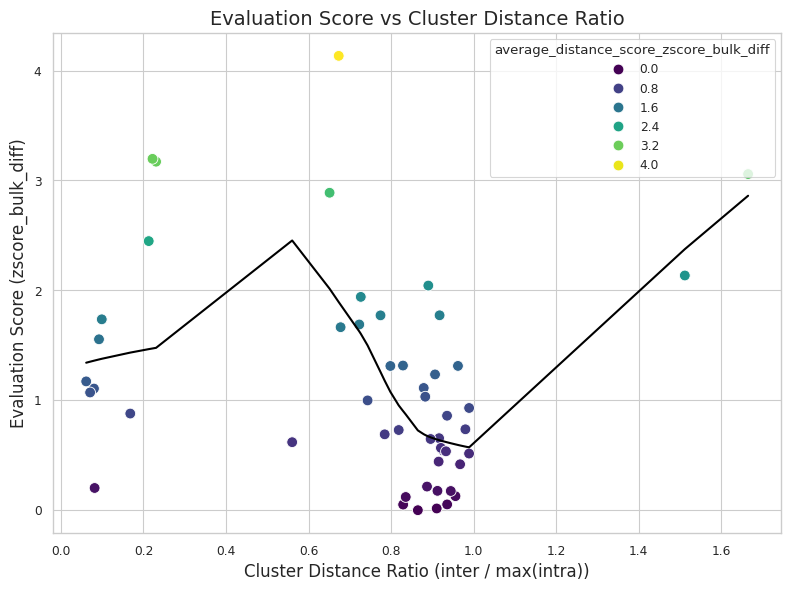

In [32]:
# Make sure the two relevant columns exist
x = "cluster_dist_ratio"
y = "average_distance_score_zscore_bulk_diff"

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=new_res,
    x=x,
    y=y,
    hue=y,          # optional: color points by score
    palette="viridis",
    s=60
)

sns.regplot(
    data=new_res,
    x=x,
    y=y,
    scatter=False,
    lowess=True,
    color="black",
    line_kws={"linewidth": 1.5},
)

plt.title("Evaluation Score vs Cluster Distance Ratio", fontsize=14)
plt.xlabel("Cluster Distance Ratio (inter / max(intra))", fontsize=12)
plt.ylabel("Evaluation Score (zscore_bulk_diff)", fontsize=12)

plt.tight_layout()
plt.show()

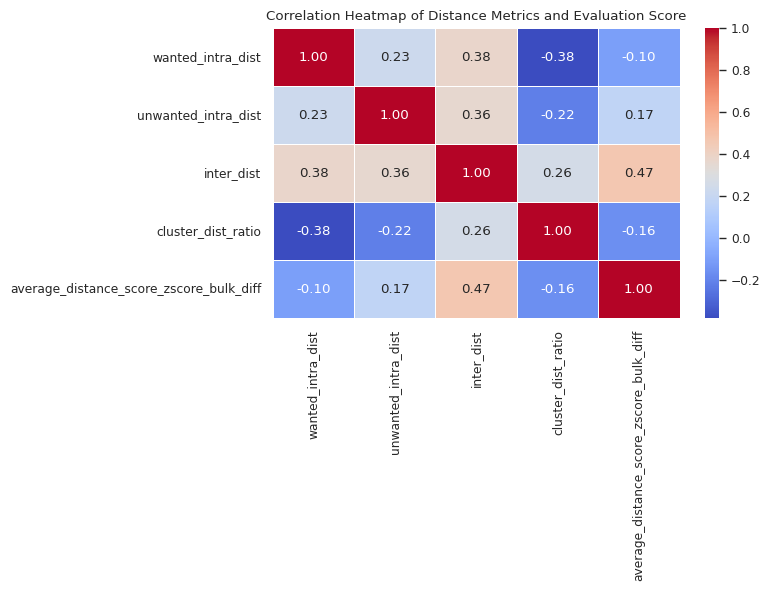

In [33]:
corr_cols = [
    "wanted_intra_dist",
    "unwanted_intra_dist",
    "inter_dist",
    "cluster_dist_ratio",
    "average_distance_score_zscore_bulk_diff"
]

# Extract relevant correlations
corr_matrix = new_res[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Distance Metrics and Evaluation Score")
plt.tight_layout()
plt.show()

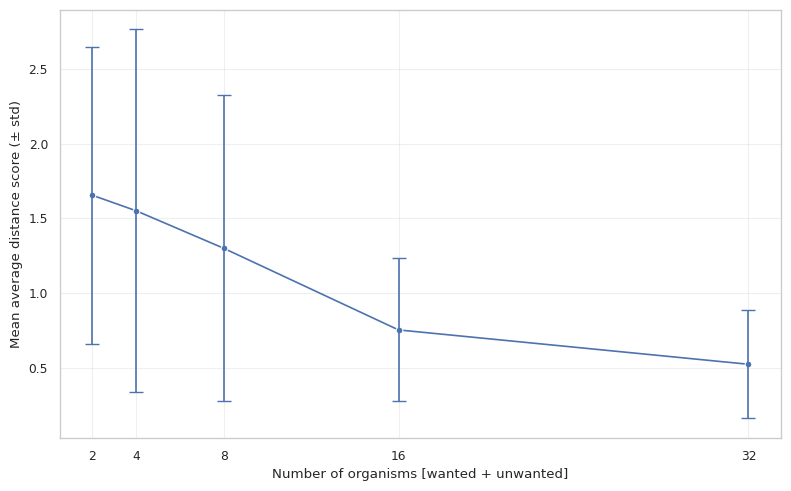

In [34]:
# --- 1. Compute size of wanted_organisms cluster ---
df_plot = new_res.copy()

df_plot["wanted_count"] = df_plot["wanted_organisms"].str.split("|").apply(len)

# --- 2. Group by wanted_count and compute mean & std ---
score_col = "average_distance_score_zscore_bulk_diff"

df_summary = (
    df_plot
    .groupby("wanted_count")[score_col]
    .agg(["mean", "std"])
    .reset_index()
)

x_vals = df_summary["wanted_count"] * 2

# --- 3. Plot mean with error bars (std) ---
plt.figure(figsize=(8, 5))
sns.lineplot(
    # data=df_summary,
    x=x_vals,
    y=df_summary["mean"],
    marker="o"
)

# Add error bars manually
plt.errorbar(
    x_vals,
    df_summary["mean"],
    yerr=df_summary["std"],
    fmt="none",
    capsize=5,
)

plt.xlabel("Number of organisms [wanted + unwanted]")
plt.ylabel("Mean average distance score (± std)")
# plt.title("Effect of Cluster Size on Average Distance Score")
plt.grid(True, alpha=0.3)
plt.xticks(x_vals)
plt.tight_layout()
plt.show()

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


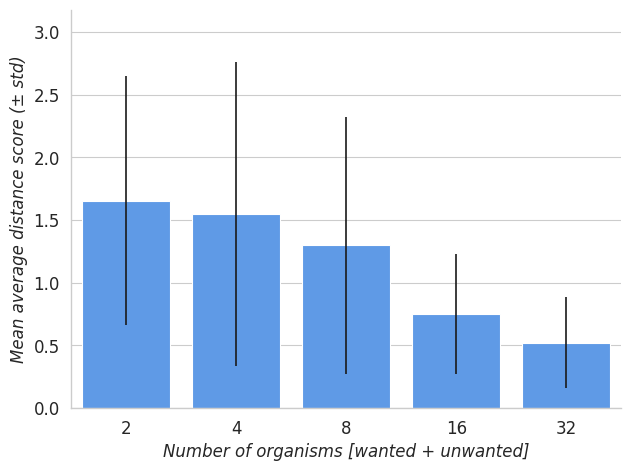

In [35]:
# --- 1. Compute size of wanted_organisms cluster ---
df_plot = new_res.copy()

df_plot["wanted_count"] = df_plot["wanted_organisms"].str.split("|").apply(len)

# --- 2. Group by wanted_count and compute mean & std ---
score_col = "average_distance_score_zscore_bulk_diff"

df_summary = (
    df_plot
    .groupby("wanted_count")[score_col]
    .agg(["mean", "std"])
    .reset_index()
)

x_vals = df_summary["wanted_count"] * 2
sns.set(style="whitegrid", context="paper") 
sns.barplot(
    data=df_summary,
    x=x_vals,
    y="mean",
    yerr=df_summary["std"],
    color="#4997fc",    # Light blue color as in your example
    capsize=5,
)

plt.xlabel("Number of organisms [wanted + unwanted]", fontsize=12, fontstyle='italic')
plt.ylabel("Mean average distance score (± std)", fontsize=12, fontstyle='italic')
# plt.title("Dependence on microbiome size", fontsize=15)
plt.ylim(0, max(df_summary["mean"] + df_summary["std"]) * 1.15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

### Cluster 1 Deep-Dive: Reviewer Analyses

Addresses the reviewer question: *what can we say about cluster 1?*  

Five analyses: (1) within-cluster CUB dispersion, (2) within-cluster K2P dispersion,
(3) cluster size and composition, (4) between-cluster separation from the unwanted hosts,
(5) objective-sensitivity — does clustering benefit correlate with within-cluster homogeneity?

**Prerequisites:** run the *Cluster vs All* section first so that `pairwise_distances_df`,
`cai_distance_df`, `organism_clusters`, `cluster_vs_all_enhanced`, and `one_vs_all_enhanced`
are in memory.

In [ ]:
SCORE_COL = "average_distance_score_zscore_bulk_ratio"

# helper: mean of the upper triangle of a sub-distance matrix
def _mean_pairwise(dist_df, organisms):
    orgs = [o for o in organisms if o in dist_df.index and o in dist_df.columns]
    if len(orgs) < 2:
        return np.nan
    sub = dist_df.loc[orgs, orgs].values
    idx = np.triu_indices(len(orgs), k=1)
    return np.nanmean(sub[idx])

# Analyses 1 + 2 + 3: per-cluster summary table
rows = []
for cid, cluster_orgs in enumerate(organism_clusters, start=1):
    rows.append({
        "cluster_id":     cid,
        "n_organisms":    len(cluster_orgs),
        "cub_dispersion": _mean_pairwise(cai_distance_df, cluster_orgs),
        "k2p_dispersion": _mean_pairwise(pairwise_distances_df, cluster_orgs),
        "organisms":      ", ".join(sorted(cluster_orgs)),
    })

cluster_profile = pd.DataFrame(rows).set_index("cluster_id")
display(
    cluster_profile[["n_organisms", "cub_dispersion", "k2p_dispersion", "organisms"]]
    .style.format({"cub_dispersion": "{:.4f}", "k2p_dispersion": "{:.4f}"})
    .set_caption("Table 1 - Per-cluster size and within-cluster CUB/K2P dispersion")
)

In [ ]:
sns.set(style="whitegrid", context="paper", font_scale=1.15)
palette_4 = sns.color_palette("tab10", len(cluster_profile))
cluster_ids = cluster_profile.index.tolist()
x = np.arange(len(cluster_ids))
xlabels = [f"C{c}" for c in cluster_ids]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Within-cluster properties by cluster",
             fontsize=13, fontweight="bold", y=1.02)

metrics = [
    ("n_organisms",    "Cluster size (# organisms)",
     "Cluster size"),
    ("cub_dispersion", "Within-cluster CUB dispersion\n(mean pairwise 1-Spearman r)",
     "CUB dispersion"),
    ("k2p_dispersion", "Within-cluster K2P dispersion\n(mean pairwise K2P distance)",
     "K2P dispersion"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    vals = cluster_profile[col]
    bars = ax.bar(x, vals, color=palette_4, edgecolor="white", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for bar, val in zip(bars, vals):
        if not np.isnan(float(val)):
            label = str(int(val)) if col == "n_organisms" else f"{val:.3f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                float(bar.get_height()) * 1.02,
                label, ha="center", va="bottom", fontsize=9,
            )

sns.despine()
plt.tight_layout()
plt.savefig("cluster_dispersion_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Analysis 4: separation of each cluster's wanted organisms from the unwanted hosts

def _mean_inter_group(dist_df, g1, g2):
    a = [o for o in g1 if o in dist_df.index and o in dist_df.columns]
    b = [o for o in g2 if o in dist_df.index and o in dist_df.columns]
    if not a or not b:
        return np.nan
    return dist_df.loc[a, b].values.mean()

runs = cluster_vs_all_enhanced.copy()
runs["wanted_list"]   = runs["wanted_organisms"].str.split("|")
runs["unwanted_list"] = runs["unwanted_organisms"].str.split("|")

runs["k2p_sep"] = runs.apply(
    lambda r: _mean_inter_group(pairwise_distances_df, r["wanted_list"], r["unwanted_list"]),
    axis=1
)
runs["cub_sep"] = runs.apply(
    lambda r: _mean_inter_group(cai_distance_df, r["wanted_list"], r["unwanted_list"]),
    axis=1
)

sep = (
    runs.groupby("cluster_id")[["k2p_sep", "cub_sep"]]
    .mean()
    .sort_index()
    .rename(columns={"k2p_sep": "K2P (wanted->unwanted)",
                     "cub_sep": "CUB (wanted->unwanted)"})
)
display(
    sep.style.format("{:.4f}")
    .set_caption("Table 2 - Mean distance from each cluster to the unwanted hosts")
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Separation of each cluster from the unwanted-host set",
             fontsize=12, fontweight="bold", y=1.02)

for ax, col, ylabel in [
    (axes[0], "K2P (wanted->unwanted)", "Mean K2P distance"),
    (axes[1], "CUB (wanted->unwanted)", "Mean CUB distance (1-Spearman)"),
]:
    bars = ax.bar(
        np.arange(len(sep)), sep[col],
        color=palette_4[:len(sep)], edgecolor="white", linewidth=1.2
    )
    ax.set_xticks(np.arange(len(sep)))
    ax.set_xticklabels([f"C{c}" for c in sep.index], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(col, fontsize=11, fontweight="bold")
    for bar, val in zip(bars, sep[col]):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    float(bar.get_height()) * 1.02,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig("cluster_separation_from_unwanted.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Analysis 5: does clustering benefit correlate with within-cluster homogeneity?
# Clustering benefit = cluster_score - mean(single-organism scores in that cluster)

org_to_cid = {}
for cid, orgs in enumerate(organism_clusters, start=1):
    for o in orgs:
        org_to_cid[o] = cid

single_scores = (
    one_vs_all_enhanced[["wanted_organisms", SCORE_COL]]
    .rename(columns={"wanted_organisms": "organism", SCORE_COL: "single_score"})
)
single_scores["cluster_id"] = single_scores["organism"].map(org_to_cid)
single_mean = (
    single_scores.dropna(subset=["cluster_id"])
    .groupby("cluster_id")["single_score"]
    .mean()
    .rename("single_mean_score")
)

cluster_score = (
    cluster_vs_all_enhanced.groupby("cluster_id")[SCORE_COL]
    .mean()
    .rename("cluster_score")
)

sens = (
    cluster_profile[["n_organisms", "cub_dispersion", "k2p_dispersion"]]
    .join(single_mean)
    .join(cluster_score)
)
sens["clustering_benefit"] = sens["cluster_score"] - sens["single_mean_score"]

display(
    sens[["n_organisms", "cub_dispersion", "k2p_dispersion",
          "cluster_score", "single_mean_score", "clustering_benefit"]]
    .style.format({c: "{:.4f}" for c in sens.columns if c != "n_organisms"})
    .set_caption("Table 3 - Clustering benefit vs within-cluster dispersion")
)

sns.set(style="whitegrid", context="paper", font_scale=1.15)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Objective-sensitivity: clustering benefit vs within-cluster dispersion",
             fontsize=12, fontweight="bold", y=1.02)

for ax, x_col, xlabel in [
    (axes[0], "cub_dispersion", "Within-cluster CUB dispersion (1-Spearman r)"),
    (axes[1], "k2p_dispersion", "Within-cluster K2P dispersion"),
]:
    for (cid, row), color in zip(sens.iterrows(), palette_4):
        ax.scatter(
            row[x_col], row["clustering_benefit"],
            s=120, color=color, edgecolor="white", linewidth=1.5, zorder=3,
            label=f"C{cid} (n={int(row['n_organisms'])})",
        )
        ax.annotate(
            f"C{cid}",
            (row[x_col], row["clustering_benefit"]),
            textcoords="offset points", xytext=(6, 4), fontsize=9,
        )

    mask = sens[x_col].notna() & sens["clustering_benefit"].notna()
    if mask.sum() >= 2:
        r, p = stats.pearsonr(sens.loc[mask, x_col], sens.loc[mask, "clustering_benefit"])
        ax.annotate(
            f"Pearson r = {r:.2f}\np = {p:.2f}",
            xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        )

    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Clustering benefit\n(cluster score - mean single score)", fontsize=10)
    ax.legend(title="Cluster", fontsize=8, title_fontsize=9, loc="lower right")

sns.despine()
plt.tight_layout()
plt.savefig("cluster_sensitivity_analysis.pdf", dpi=300, bbox_inches="tight")
plt.show()

#### CUB:K2P ratio — the key predictor of clustering benefit

When the ratio is ~1, codon-usage divergence tracks phylogenetic divergence:
organisms share a coherent CUB profile and joint optimization can exploit it.
When the ratio >> 1, CUB has diverged beyond phylogeny (organism-specific pressures),
creating conflicting optimization targets that joint optimization cannot resolve.

,n_organisms,cub_dispersion,k2p_dispersion,cub_k2p_ratio,clustering_benefit
cluster_id,,,,,
1,23,0.072,0.072,1.005,3.597
2,2,0.011,0.011,0.949,0.270
3,4,0.091,0.015,6.210,0.048
4,5,0.182,0.025,7.141,-0.364


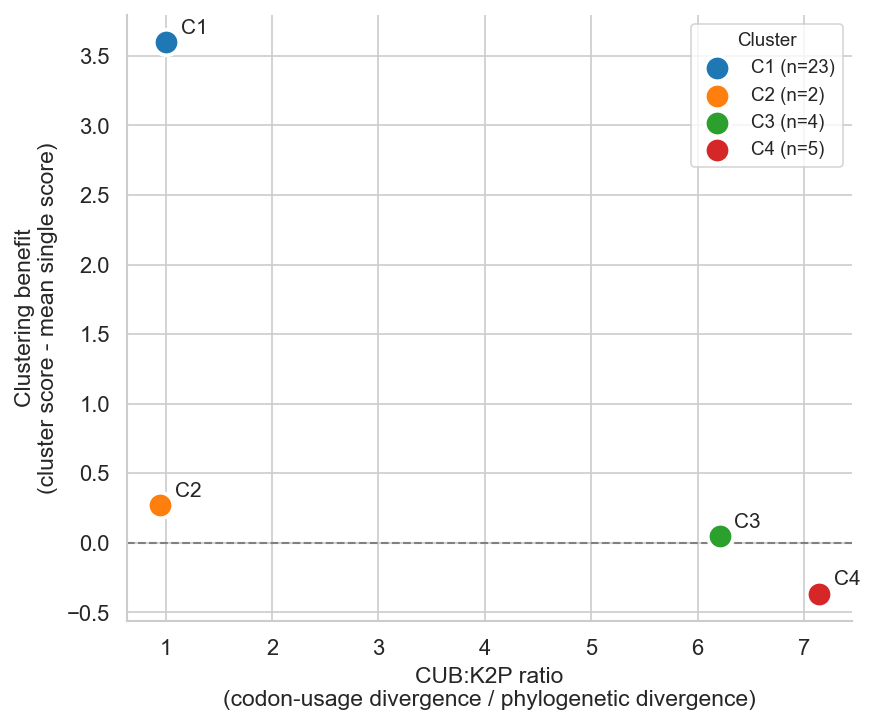

In [1]:
# Add CUB:K2P ratio to the cluster profile built in cell 51
cluster_profile["cub_k2p_ratio"] = (
    cluster_profile["cub_dispersion"] / cluster_profile["k2p_dispersion"]
)

# Re-compute clustering benefit so this cell can run standalone if needed
org_to_cid_ratio = {o: cid for cid, orgs in enumerate(organism_clusters, start=1) for o in orgs}
_single = (
    one_vs_all_enhanced[["wanted_organisms", SCORE_COL]]
    .rename(columns={"wanted_organisms": "organism", SCORE_COL: "single_score"})
)
_single["cluster_id"] = _single["organism"].map(org_to_cid_ratio)
_single_mean = _single.dropna(subset=["cluster_id"]).groupby("cluster_id")["single_score"].mean()
_cluster_score = cluster_vs_all_enhanced.groupby("cluster_id")[SCORE_COL].mean()
cluster_profile["clustering_benefit"] = _cluster_score - _single_mean

display(
    cluster_profile[["n_organisms", "cub_dispersion", "k2p_dispersion",
                      "cub_k2p_ratio", "clustering_benefit"]]
    .style.format({c: "{:.3f}" for c in cluster_profile.columns if c != "n_organisms"})
    .set_caption("Table 4 - CUB:K2P ratio and clustering benefit (monotone relationship)")
)

# Scatter: CUB:K2P ratio vs clustering benefit
sns.set(style="whitegrid", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(6, 5))

palette_4 = sns.color_palette("tab10", len(cluster_profile))
for (cid, row), color in zip(cluster_profile.iterrows(), palette_4):
    ax.scatter(row["cub_k2p_ratio"], row["clustering_benefit"],
               s=150, color=color, edgecolor="white", linewidth=1.8,
               zorder=3, label=f"C{cid} (n={int(row['n_organisms'])})")
    ax.annotate(f"C{cid}", (row["cub_k2p_ratio"], row["clustering_benefit"]),
                textcoords="offset points", xytext=(7, 4), fontsize=10)

ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("CUB:K2P ratio\n(codon-usage divergence / phylogenetic divergence)", fontsize=11)
ax.set_ylabel("Clustering benefit\n(cluster score - mean single score)", fontsize=11)
ax.legend(title="Cluster", fontsize=9, title_fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig("cub_k2p_ratio_vs_benefit.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Hypothesis: C1's large size inflates same-cluster contamination in the single-organism benchmark

In the single-organism benchmark each organism is the sole *wanted* host;
all others are *unwanted*.  Because C1 has 23 members, a C1 organism has
22 CUB-similar organisms in its unwanted set — the optimizer is simultaneously
asked to optimise **for** and **against** nearly identical codon profiles.
Clustering moves all 23 into the wanted set, giving a clean objective.
The following analyses quantify this effect.

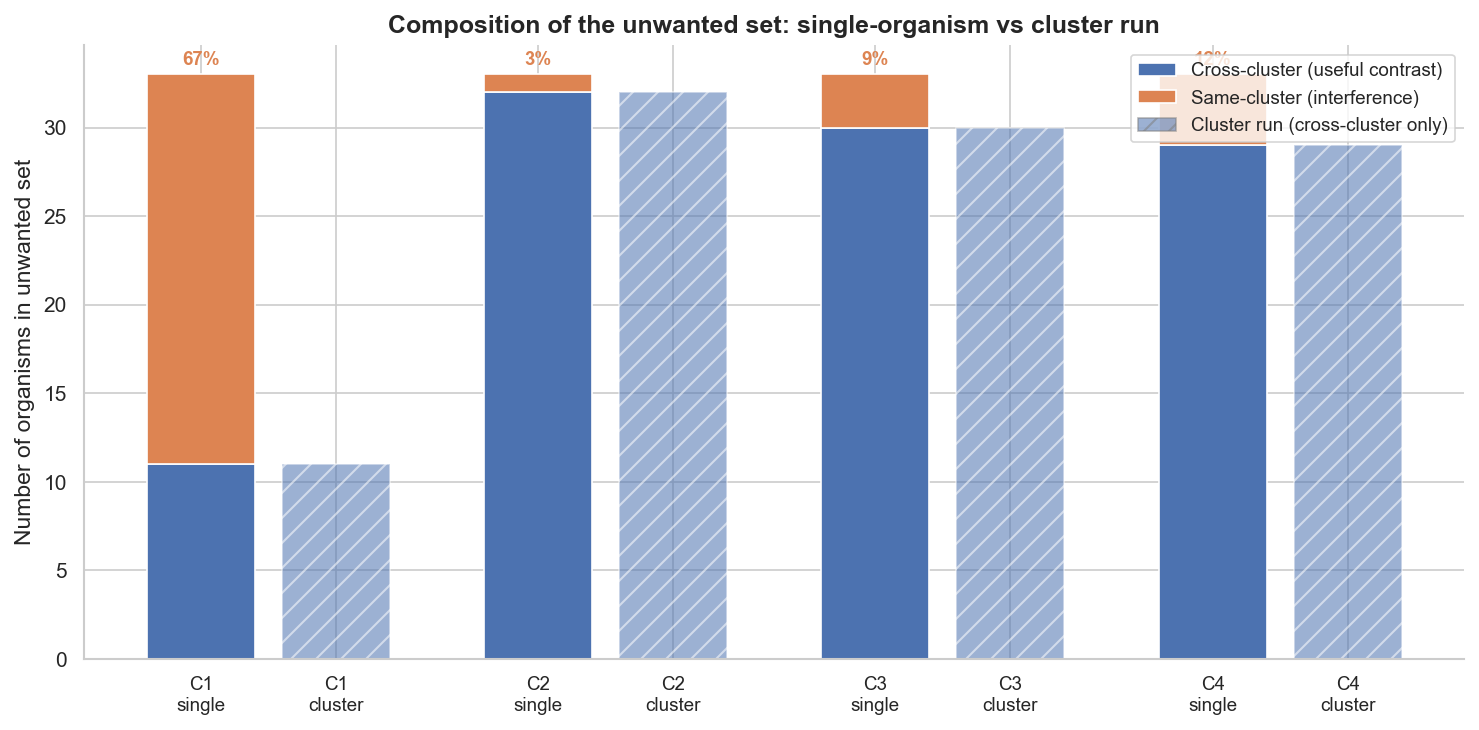

In [2]:
# ── A. Objective composition: same-cluster vs cross-cluster in the unwanted set ──

org_to_cid_c = {o: cid for cid, orgs in enumerate(organism_clusters, start=1) for o in orgs}

# Compute contamination per organism in single-organism runs
df_single = one_vs_all_enhanced[["wanted_organisms", "unwanted_organisms", SCORE_COL]].copy()
df_single["cluster_id"] = df_single["wanted_organisms"].map(org_to_cid_c)

def _contamination(row):
    uw = row["unwanted_organisms"].split("|")
    cid = row["cluster_id"]
    same  = sum(1 for o in uw if org_to_cid_c.get(o) == cid)
    cross = len(uw) - same
    return pd.Series({"n_same_unwanted": same, "n_cross_unwanted": cross,
                      "n_total_unwanted": len(uw)})

df_single = df_single.join(df_single.apply(_contamination, axis=1))
df_single["contamination_rate"] = df_single["n_same_unwanted"] / df_single["n_total_unwanted"]

per_cluster = df_single.groupby("cluster_id")[
    ["n_same_unwanted", "n_cross_unwanted"]].mean()

# For cluster runs: 0 same-cluster in unwanted by construction
cluster_run_cross = {
    cid: len([o for orgs in organism_clusters for o in orgs
               if org_to_cid_c[o] != cid])
    for cid in per_cluster.index
}

# Plot: stacked bars side by side (single vs cluster run)
sns.set(style="whitegrid", context="paper", font_scale=1.15)
fig, ax = plt.subplots(figsize=(10, 5))

cids = sorted(per_cluster.index.tolist())
x_single  = np.arange(len(cids)) * 2.5
x_cluster = x_single + 1.0
bar_w = 0.8

colors_cross = "#4C72B0"   # blue  = genuinely cross-cluster (useful signal)
colors_same  = "#DD8452"   # orange = same-cluster contamination (interference)

# Single bars
same_vals  = [per_cluster.loc[c, "n_same_unwanted"]  for c in cids]
cross_vals = [per_cluster.loc[c, "n_cross_unwanted"] for c in cids]
bar1 = ax.bar(x_single, cross_vals, bar_w, color=colors_cross, label="Cross-cluster (useful contrast)")
bar2 = ax.bar(x_single, same_vals,  bar_w, bottom=cross_vals, color=colors_same,
              label="Same-cluster (interference)")

# Cluster bars
cluster_cross_vals = [cluster_run_cross[c] for c in cids]
ax.bar(x_cluster, cluster_cross_vals, bar_w, color=colors_cross, alpha=0.55,
       hatch="//", edgecolor="white")

# Contamination-rate annotation above single bars
for xi, (same, cross) in zip(x_single, zip(same_vals, cross_vals)):
    total = same + cross
    rate = same / total if total else 0
    ax.text(xi, total + 0.3, f"{rate:.0%}", ha="center", va="bottom",
            fontsize=9, color=colors_same, fontweight="bold")

tick_positions = sorted(x_single.tolist() + x_cluster.tolist())
tick_labels = []
for c in cids:
    tick_labels += [f"C{c}\nsingle", f"C{c}\ncluster"]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylabel("Number of organisms in unwanted set", fontsize=11)
ax.set_title("Composition of the unwanted set: single-organism vs cluster run",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_cross, label="Cross-cluster (useful contrast)"),
    Patch(facecolor=colors_same,  label="Same-cluster (interference)"),
    Patch(facecolor=colors_cross, alpha=0.55, hatch="//",
          edgecolor="grey", label="Cluster run (cross-cluster only)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")
sns.despine()
plt.tight_layout()
plt.savefig("objective_composition_single_vs_cluster.pdf", dpi=300, bbox_inches="tight")
plt.show()

Effective CUB contrast per cluster:


,cub_to_same,cub_to_cross,cub_to_all,cub_cluster_run
cluster_id,,,,
1,0.0722,0.8793,0.3413,0.8793
2,0.0107,0.3481,0.3379,0.3481
3,0.0905,1.0416,0.9551,1.0416
4,0.1820,0.8234,0.7457,0.8234


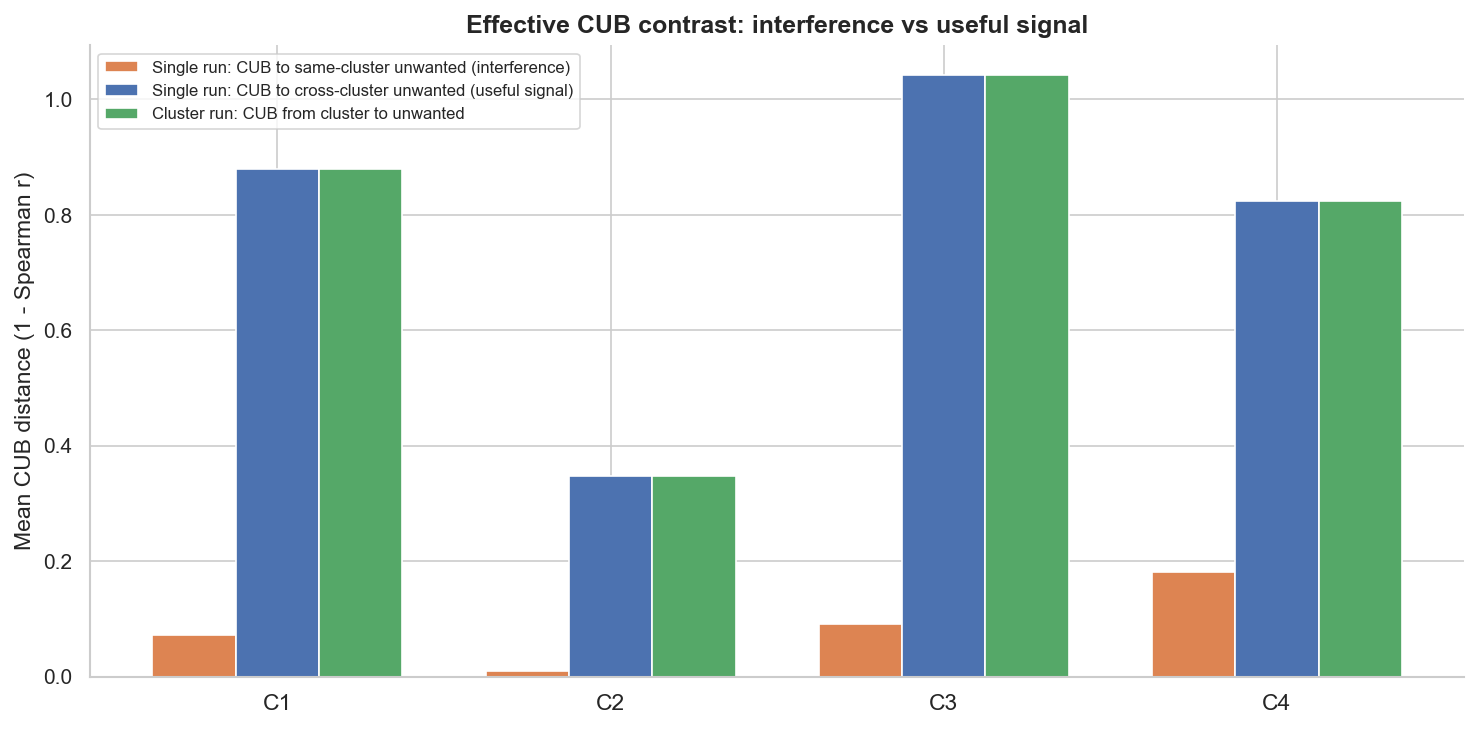

In [3]:
# ── B. Effective CUB contrast: how much of the unwanted set is actually distant? ──
# For each single-organism run compute:
#   cub_to_same   = mean CUB distance from wanted org to same-cluster unwanted (interference)
#   cub_to_cross  = mean CUB distance from wanted org to cross-cluster unwanted (useful signal)
# Then compare the cluster run's effective CUB separation.

def _cub_distances(row):
    wanted = row["wanted_organisms"]
    cid = org_to_cid_c.get(wanted)
    uw  = row["unwanted_organisms"].split("|")
    same_uw  = [o for o in uw if org_to_cid_c.get(o) == cid and o in cai_distance_df.columns]
    cross_uw = [o for o in uw if org_to_cid_c.get(o) != cid and o in cai_distance_df.columns]
    if wanted not in cai_distance_df.index:
        return pd.Series({"cub_to_same": np.nan, "cub_to_cross": np.nan,
                          "cub_to_all":  np.nan})
    to_same  = cai_distance_df.loc[wanted, same_uw].mean()  if same_uw  else np.nan
    to_cross = cai_distance_df.loc[wanted, cross_uw].mean() if cross_uw else np.nan
    to_all   = cai_distance_df.loc[wanted, [o for o in uw if o in cai_distance_df.columns]].mean()
    return pd.Series({"cub_to_same": to_same, "cub_to_cross": to_cross,
                      "cub_to_all": to_all})

df_single = df_single.join(df_single.apply(_cub_distances, axis=1))

# For cluster runs: CUB distance from cluster centroid to the cross-cluster unwanted set
cluster_cub_to_unwanted = {}
for cid, wanted_orgs in enumerate(organism_clusters, start=1):
    unwanted_orgs = [o for o in org_to_cid_c if org_to_cid_c[o] != cid
                     and o in cai_distance_df.columns]
    w = [o for o in wanted_orgs if o in cai_distance_df.index]
    if w and unwanted_orgs:
        cluster_cub_to_unwanted[cid] = cai_distance_df.loc[w, unwanted_orgs].values.mean()
    else:
        cluster_cub_to_unwanted[cid] = np.nan

# Aggregate per cluster
cub_summary = df_single.groupby("cluster_id")[["cub_to_same","cub_to_cross","cub_to_all"]].mean()
cub_summary["cub_cluster_run"] = pd.Series(cluster_cub_to_unwanted)
print("Effective CUB contrast per cluster:")
display(
    cub_summary.style.format("{:.4f}")
    .set_caption("Table 5 - CUB distances from wanted organisms to same-cluster vs cross-cluster unwanted")
)

# Plot: grouped bar — single (same / cross) vs cluster run
sns.set(style="whitegrid", context="paper", font_scale=1.15)
fig, ax = plt.subplots(figsize=(10, 5))

cids = sorted(cub_summary.index.tolist())
x = np.arange(len(cids))
w = 0.25

ax.bar(x - w, cub_summary.loc[cids, "cub_to_same"],  w, color="#DD8452",
       label="Single run: CUB to same-cluster unwanted (interference)")
ax.bar(x,     cub_summary.loc[cids, "cub_to_cross"], w, color="#4C72B0",
       label="Single run: CUB to cross-cluster unwanted (useful signal)")
ax.bar(x + w, cub_summary.loc[cids, "cub_cluster_run"], w, color="#55A868",
       label="Cluster run: CUB from cluster to unwanted")

ax.set_xticks(x)
ax.set_xticklabels([f"C{c}" for c in cids], fontsize=11)
ax.set_ylabel("Mean CUB distance (1 - Spearman r)", fontsize=11)
ax.set_title("Effective CUB contrast: interference vs useful signal",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig("cub_contrast_interference_vs_signal.pdf", dpi=300, bbox_inches="tight")
plt.show()

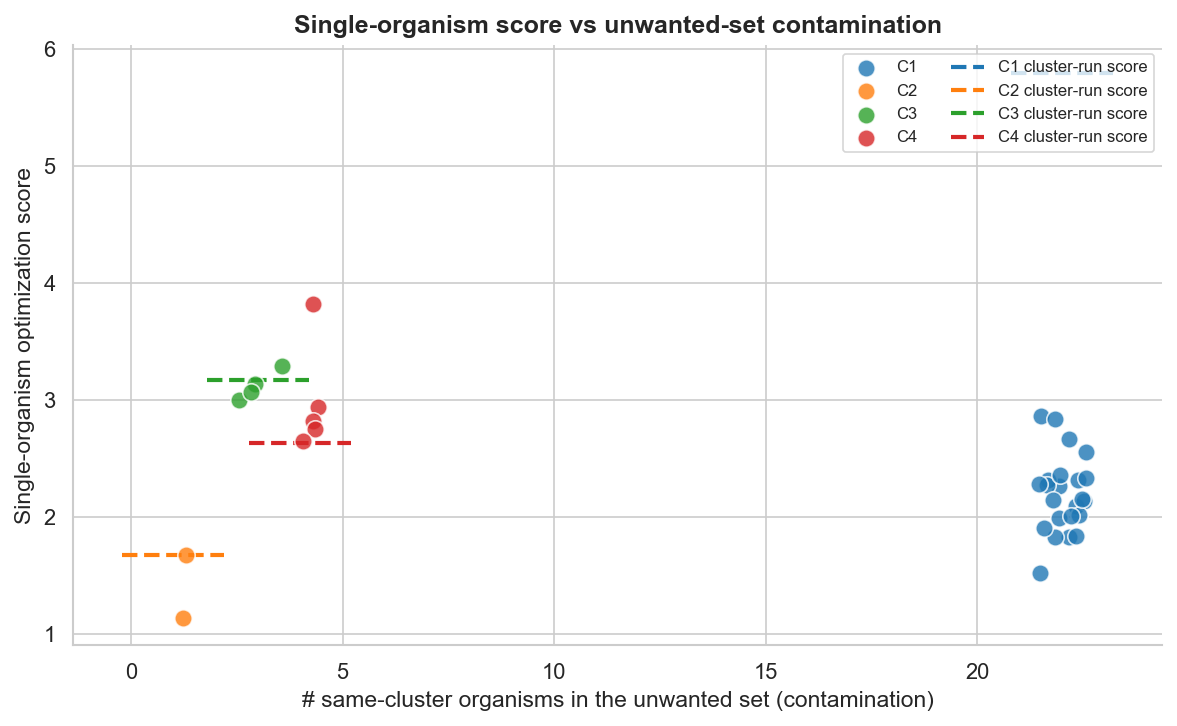

In [4]:
# ── C. Single-organism score vs same-cluster contamination ───────────────────
# Each point is one organism. Contamination count is discrete (1, 3, 4, 22)
# because it depends only on cluster size.
# Jitter on x for readability.

rng = np.random.default_rng(42)
df_plot = df_single.copy()
df_plot["cluster_label"] = df_plot["cluster_id"].apply(lambda c: f"C{int(c)}")
df_plot["x_jitter"] = (
    df_plot["n_same_unwanted"]
    + rng.uniform(-0.6, 0.6, size=len(df_plot))
)

palette_c = dict(zip([f"C{c}" for c in sorted(df_plot['cluster_id'].unique())],
                      sns.color_palette("tab10", 4)))

sns.set(style="whitegrid", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 5))

for label, grp in df_plot.groupby("cluster_label"):
    ax.scatter(grp["x_jitter"], grp[SCORE_COL],
               color=palette_c[label], s=70, alpha=0.8,
               edgecolor="white", linewidth=0.8, label=label, zorder=3)

# Reference line: the cluster run score per cluster
cluster_scores_ref = cluster_vs_all_enhanced.groupby("cluster_id")[SCORE_COL].mean()
for (cid, orgs), color in zip(enumerate(organism_clusters, start=1),
                               sns.color_palette("tab10", 4)):
    n_same = len(orgs) - 1
    ax.hlines(cluster_scores_ref[cid], n_same - 1.2, n_same + 1.2,
              colors=color, linewidths=2, linestyles="--",
              label=f"C{cid} cluster-run score")

ax.set_xlabel("# same-cluster organisms in the unwanted set (contamination)", fontsize=11)
ax.set_ylabel("Single-organism optimization score", fontsize=11)
ax.set_title("Single-organism score vs unwanted-set contamination",
             fontsize=12, fontweight="bold")

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
ax.legend(*zip(*unique), fontsize=8, ncol=2)
sns.despine()
plt.tight_layout()
plt.savefig("single_score_vs_contamination.pdf", dpi=300, bbox_inches="tight")
plt.show()

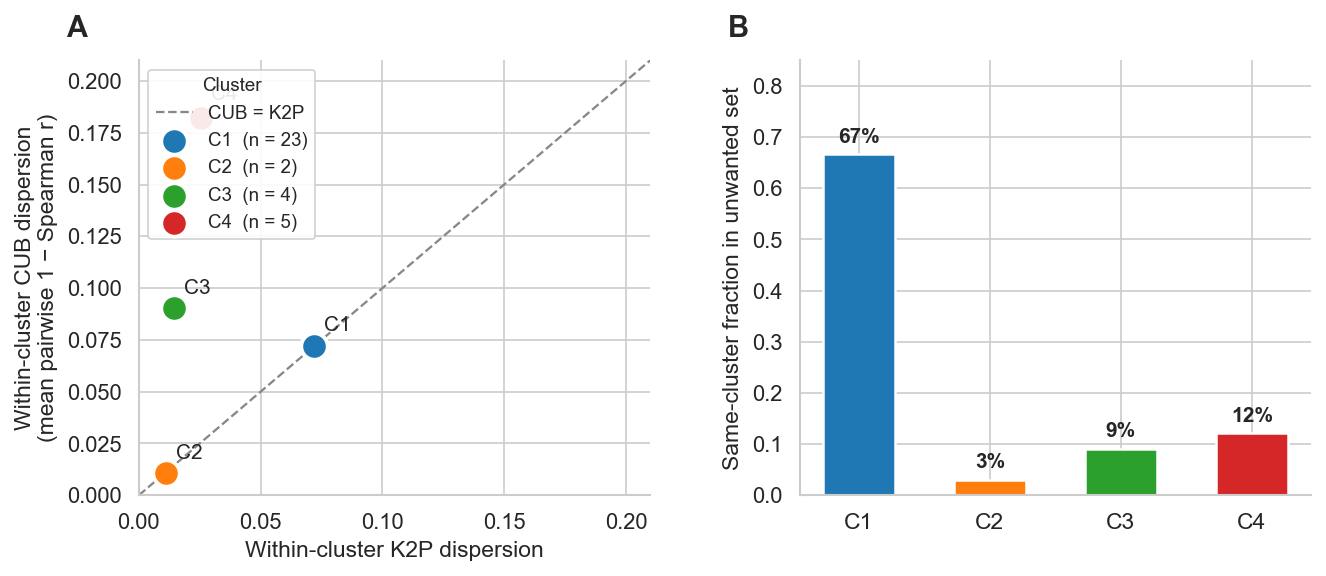

In [5]:
# Two-panel summary figure
# (A) within-cluster CUB vs K2P dispersion
# (B) same-cluster contamination fraction in the unwanted set

sns.set(style="whitegrid", context="paper", font_scale=1.2)
palette_4 = sns.color_palette("tab10", 4)
cids = sorted(cluster_profile.index.tolist())
total_orgs = sum(len(o) for o in organism_clusters)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel A
ax = axes[0]
ax_lim = 0.21
ax.plot([0, ax_lim], [0, ax_lim], color="#888888", linestyle="--",
        linewidth=1.1, zorder=1, label="CUB = K2P")
for (cid, row), color in zip(cluster_profile.iterrows(), palette_4):
    ax.scatter(row["k2p_dispersion"], row["cub_dispersion"],
               s=160, color=color, edgecolor="white", linewidth=1.8,
               zorder=3, label=f"C{cid}  (n = {int(row['n_organisms'])})")
    dx, dy = (0.004, 0.005) if row["cub_dispersion"] < 0.1 else (0.004, 0.007)
    ax.annotate(f"C{cid}",
                xy=(row["k2p_dispersion"], row["cub_dispersion"]),
                xytext=(row["k2p_dispersion"] + dx, row["cub_dispersion"] + dy),
                fontsize=10, va="bottom")
ax.set_xlim(0, ax_lim); ax.set_ylim(0, ax_lim)
ax.set_xlabel("Within-cluster K2P dispersion", fontsize=11)
ax.set_ylabel("Within-cluster CUB dispersion\n(mean pairwise 1 \u2212 Spearman r)", fontsize=11)
ax.legend(fontsize=9, title="Cluster", title_fontsize=9, loc="upper left", framealpha=0.9)

# Panel B
ax = axes[1]
contam = [(len(organism_clusters[cid-1]) - 1) / (total_orgs - 1) for cid in cids]
bars = ax.bar(np.arange(len(cids)), contam, color=palette_4,
              edgecolor="white", linewidth=1.2, width=0.55)
for bar, val in zip(bars, contam):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
            f"{val:.0%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(np.arange(len(cids)))
ax.set_xticklabels([f"C{c}" for c in cids], fontsize=11)
ax.set_ylabel("Same-cluster fraction in unwanted set", fontsize=11)
ax.set_ylim(0, 0.85)

for ax_i, label in zip(axes, ["A", "B"]):
    ax_i.text(-0.14, 1.04, label, transform=ax_i.transAxes,
              fontsize=14, fontweight="bold", va="bottom", ha="left")

sns.despine()
plt.tight_layout(w_pad=3)
plt.savefig("cluster1_coherence_contamination.svg", format="svg", bbox_inches="tight")
plt.show()

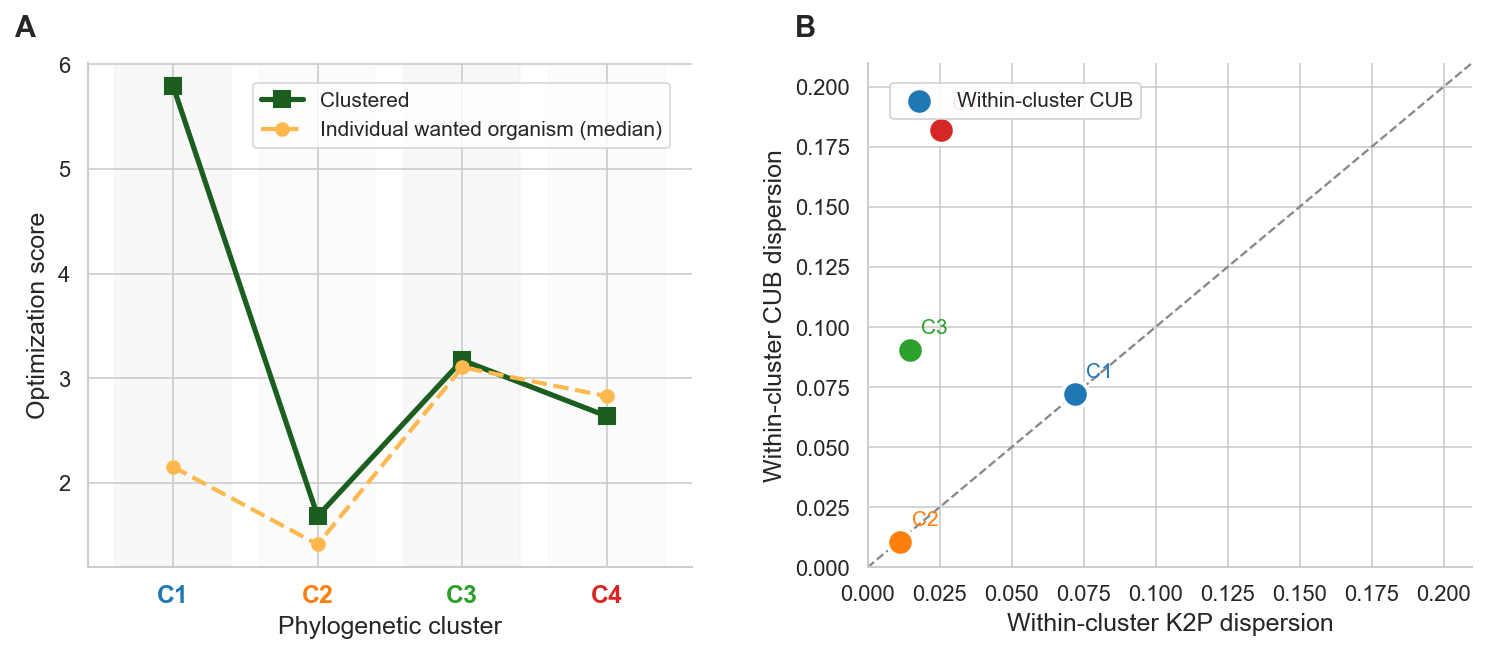

In [7]:
# Two-panel figure
# (A) Clustered vs single-organism optimization scores (from cell 37)
# (B) Within-cluster CUB vs K2P dispersion

from matplotlib.lines import Line2D

sns.set(style="whitegrid", context="paper", font_scale=1.2)
palette_4 = sns.color_palette("tab10", 4)
cluster_order = sorted(cluster_summary["cluster_id"].unique())
x_pos = np.arange(len(cluster_order))
cs_idx = cluster_summary.set_index("cluster_id")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ── Panel A ──────────────────────────────────────────────────────────
ax = axes[0]
for i, cid in enumerate(cluster_order):
    ax.axvspan(i - 0.4, i + 0.4,
               color="lightgrey", alpha=0.15 if i % 2 == 0 else 0.08, zorder=0)
ax.plot(x_pos, cs_idx.loc[cluster_order, "cluster_score"],
        "s-", color="#1B5E20", linewidth=2.5, markersize=8, label="Clustered", zorder=3)
ax.plot(x_pos, cs_idx.loc[cluster_order, "single_median_score"],
        "o--", color="#FFB84D", linewidth=2.0, markersize=6,
        label="Individual wanted organism (median)", zorder=3)
ax.set_xticks(x_pos)
tick_labels = ax.set_xticklabels(
    [f"C{cid}" for cid in cluster_order], fontsize=12, fontweight="bold")
for lbl, color in zip(tick_labels, palette_4):
    lbl.set_color(color)
ax.set_xlabel("Phylogenetic cluster", fontsize=12)
ax.set_ylabel("Optimization score", fontsize=12)
ax.legend(frameon=True, fancybox=True, shadow=False, fontsize=10,
          loc="upper right", bbox_to_anchor=(0.98, 0.98))

# ── Panel B ──────────────────────────────────────────────────────────
ax = axes[1]
ax_lim = 0.21
ax.plot([0, ax_lim], [0, ax_lim],
        color="#888888", linestyle="--", linewidth=1.1, zorder=1)
first = True
for (cid, row), color in zip(cluster_profile.iterrows(), palette_4):
    label = "Within-cluster CUB" if first else "_nolegend_"
    first = False
    ax.scatter(row["k2p_dispersion"], row["cub_dispersion"],
               s=160, color=color, edgecolor="white", linewidth=1.8,
               zorder=3, label=label)
    dx, dy = 0.004, (0.005 if row["cub_dispersion"] < 0.1 else 0.007)
    ax.annotate(f"C{cid}",
                xy=(row["k2p_dispersion"], row["cub_dispersion"]),
                xytext=(row["k2p_dispersion"] + dx, row["cub_dispersion"] + dy),
                fontsize=10, va="bottom", color=palette_4[cid - 1])
ax.set_xlim(0, ax_lim); ax.set_ylim(0, ax_lim)
ax.set_xlabel("Within-cluster K2P dispersion", fontsize=12)
ax.set_ylabel("Within-cluster CUB dispersion", fontsize=12)
ax.legend(fontsize=10, framealpha=0.9, loc="upper left",
          bbox_to_anchor=(0.02, 0.98))

for ax_i, lbl in zip(axes, ["A", "B"]):
    ax_i.text(-0.12, 1.04, lbl, transform=ax_i.transAxes,
              fontsize=14, fontweight="bold", va="bottom", ha="left")

sns.despine()
plt.tight_layout(w_pad=3)
plt.savefig("cluster1_scores_and_dispersion.svg", format="svg", bbox_inches="tight")
plt.show()